In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


COLOR_1 = "tab:orange"
COLOR_0 = "tab:blue"

def find_file(*filenames):
    for filename in filenames:
        for p in [Path(filename), Path.cwd()/filename, Path("/mnt/data")/filename]:
            if p.exists():
                return p
    raise FileNotFoundError(f"Could not find any of: {filenames}")

details_path = find_file("order_details.csv", "order_details(3).csv")
timestamps_path = find_file("order_timestamp.csv", "order_timestamp(3).csv")

details = pd.read_csv(details_path)
timestamps = pd.read_csv(timestamps_path)

print("order_details shape:", details.shape)
print("order_timestamp shape:", timestamps.shape)


order_details shape: (151803, 10)
order_timestamp shape: (151803, 4)


In [2]:
for col in ["start_time_slot", "accept_time", "arrived_pickup_at"]:
    timestamps[col] = pd.to_datetime(timestamps[col], errors="coerce")

df = details.merge(
    timestamps[["order_id", "start_time_slot", "accept_time", "arrived_pickup_at"]],
    on="order_id",
    how="left",
    validate="one_to_one"
)


df["acceptance_time_raw_min"] = (
    df["accept_time"] - df["start_time_slot"]
).dt.total_seconds() / 60


df["acceptance_time_min"] = df["acceptance_time_raw_min"].clip(lower=0)

df["AcceptanceTime10"] = np.where(
    df["acceptance_time_min"].notna(),
    (df["acceptance_time_min"] <= 10).astype(int),
    np.nan
)


df["arrival_time_raw_min"] = (
    df["arrived_pickup_at"] - df["accept_time"]
).dt.total_seconds() / 60


df["arrival_time_min"] = df["arrival_time_raw_min"].clip(lower=0)

df["ArrivalTime5"] = np.where(
    df["arrival_time_min"].notna(),
    (df["arrival_time_min"] <= 5).astype(int),
    np.nan
)


df["BATR_raw_min"] = (
    df["arrived_pickup_at"] - df["start_time_slot"]
).dt.total_seconds() / 60

df["BATR_min"] = df["BATR_raw_min"].clip(lower=0)

df["BATR15"] = np.where(
    df["BATR_min"].notna(),
    (df["BATR_min"] <= 15).astype(int),
    np.nan
)


df["date"] = df["start_time_slot"].dt.floor("D")


period_mask = (
    (df["start_time_slot"] >= "2025-08-01")
    & (df["start_time_slot"] < "2025-11-01")
)

analysis_period = df[period_mask].copy()

print(f"Total orders: {len(df):,}")
print(f"Valid AcceptanceTime10: {df['AcceptanceTime10'].notna().sum():,}")
print(f"Valid ArrivalTime5: {df['ArrivalTime5'].notna().sum():,}")
print(f"Valid BATR15: {df['BATR15'].notna().sum():,}")
print(f"Negative raw ArrivalTime values set to zero: {(df['arrival_time_raw_min'] < 0).sum():,}")
print(f"Negative raw BATR values set to zero: {(df['BATR_raw_min'] < 0).sum():,}")


Total orders: 151,803
Valid AcceptanceTime10: 151,579
Valid ArrivalTime5: 151,579
Valid BATR15: 151,582
Negative raw ArrivalTime values set to zero: 23,805
Negative raw BATR values set to zero: 23,805


In [3]:
def add_stacked_percent_labels(ax, pct_df, count_df):
    for i, idx in enumerate(pct_df.index):
        bottom = 0
        for col in pct_df.columns:
            pct = float(pct_df.loc[idx, col])
            n = int(count_df.loc[idx, col])

            ax.text(
                i,
                bottom + pct / 2,
                f"{pct:.1f}%\n(n={n:,})",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold"
            )
            bottom += pct


def metric_city_tables(data, metric):
    counts = (
        data.groupby(["order_city", metric])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=[0, 1], fill_value=0)
    )

    pct = counts.div(counts.sum(axis=1), axis=0) * 100

    summary = pd.DataFrame({
        "Orders": counts.sum(axis=1),
        f"{metric} = 0 (%)": pct[0],
        f"{metric} = 1 (%)": pct[1],
    }).sort_index()

    return counts, pct, summary


def metric_district_tables(data, metric):
    counts = (
        data.groupby(["order_city", "district", metric])
            .size()
            .unstack(fill_value=0)
            .reindex(columns=[0, 1], fill_value=0)
    )

    pct = counts.div(counts.sum(axis=1), axis=0) * 100

    summary = counts.copy()
    summary.columns = [f"{metric}_0_Count", f"{metric}_1_Count"]
    summary["Orders"] = summary.sum(axis=1)
    summary[f"{metric} = 0 (%)"] = pct[0]
    summary[f"{metric} = 1 (%)"] = pct[1]

    summary = summary[
        [
            "Orders",
            f"{metric}_0_Count",
            f"{metric}_1_Count",
            f"{metric} = 0 (%)",
            f"{metric} = 1 (%)"
        ]
    ]
    return counts, pct, summary


def plot_city_stacked(counts, pct, metric, title):


    plot_df = pct[[1, 0]].copy()
    plot_counts = counts[[1, 0]].copy()

    ax = plot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(10, 6),
        width=0.65,
        color=[COLOR_1, COLOR_0]
    )

    add_stacked_percent_labels(ax, plot_df, plot_counts)

    ax.set_title(title, fontsize=15, pad=12)
    ax.set_xlabel("City")
    ax.set_ylabel("Percentage of Orders (%)")
    ax.set_ylim(0, 100)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(
        [f"{metric} = 1", f"{metric} = 0"],
        title="Status",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_district_stacked(city, counts, summary, metric, title_prefix):
    sub_counts = counts.loc[city].copy().sort_index()
    sub_pct = sub_counts.div(sub_counts.sum(axis=1), axis=0) * 100

    plot_df = sub_pct[[1, 0]].copy()
    plot_counts = sub_counts[[1, 0]].copy()

    plot_df.index = plot_df.index.astype(str)
    plot_counts.index = plot_counts.index.astype(str)

    fig_width = max(11, len(plot_df) * 1.0)

    ax = plot_df.plot(
        kind="bar",
        stacked=True,
        figsize=(fig_width, 7),
        width=0.72,
        color=[COLOR_1, COLOR_0]
    )

    add_stacked_percent_labels(ax, plot_df, plot_counts)

    ax.set_title(
        f"City {city} — {title_prefix} Distribution by District",
        fontsize=15,
        pad=12
    )
    ax.set_xlabel("District")
    ax.set_ylabel("Percentage of Orders (%)")
    ax.set_ylim(0, 100)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(
        [f"{metric} = 1", f"{metric} = 0"],
        title="Status",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

    return summary.loc[city].copy().sort_index()


def rolling_metric_rate(data, metric, group_cols, window=7):
    tmp = data[data[metric].notna() & data["date"].notna()].copy()
    tmp[metric] = tmp[metric].astype(int)

    daily = (
        tmp.groupby(group_cols + ["date"])[metric]
           .agg(successes="sum", orders="count")
           .reset_index()
    )

    full_dates = pd.date_range(
        tmp["date"].min(),
        tmp["date"].max(),
        freq="D"
    )

    outputs = []

    if len(group_cols) == 1:
        grouped = daily.groupby(group_cols[0], sort=True)
    else:
        grouped = daily.groupby(group_cols, sort=True)

    for key, g in grouped:
        g = g.set_index("date").reindex(full_dates)
        g.index.name = "date"
        g["successes"] = g["successes"].fillna(0)
        g["orders"] = g["orders"].fillna(0)

        rolling_success = g["successes"].rolling(window, min_periods=1).sum()
        rolling_orders = g["orders"].rolling(window, min_periods=1).sum()

        g["rolling_rate"] = np.where(
            rolling_orders > 0,
            rolling_success / rolling_orders * 100,
            np.nan
        )
        g["rolling_orders"] = rolling_orders

        if len(group_cols) == 1:
            key = (key,)

        for col, value in zip(group_cols, key):
            g[col] = value

        outputs.append(g.reset_index())

    return pd.concat(outputs, ignore_index=True)


MONTH_BOUNDARIES = [
    pd.Timestamp("2025-09-01"),
    pd.Timestamp("2025-10-01")
]


def plot_city_trend(data, metric, title):
    trend = rolling_metric_rate(
        data,
        metric=metric,
        group_cols=["order_city"],
        window=7
    )

    fig, ax = plt.subplots(figsize=(14, 7))

    for city in ["B", "K", "U"]:
        s = trend[trend["order_city"] == city]
        ax.plot(
            s["date"],
            s["rolling_rate"],
            linewidth=2,
            label=f"City {city}"
        )

    for boundary in MONTH_BOUNDARIES:
        ax.axvline(
            boundary,
            linestyle="--",
            linewidth=1.2,
            alpha=0.7
        )

    ax.text(pd.Timestamp("2025-09-01"), 100.5, "Sep",
            ha="center", va="bottom", fontsize=9)
    ax.text(pd.Timestamp("2025-10-01"), 100.5, "Oct",
            ha="center", va="bottom", fontsize=9)

    ax.set_title(title, fontsize=15, pad=12)
    ax.set_xlabel("Date")
    ax.set_ylabel(f"{metric} = 1 (%)")
    ax.set_ylim(0, 105)
    ax.legend(title="City", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()


def plot_district_trends(data, city, metric, title_prefix):
    trend = rolling_metric_rate(
        data,
        metric=metric,
        group_cols=["order_city", "district"],
        window=7
    )

    city_data = trend[trend["order_city"] == city].copy()
    districts = sorted(city_data["district"].dropna().unique())

    fig_width = 15 if len(districts) <= 8 else 17
    fig, ax = plt.subplots(figsize=(fig_width, 8))

    for district in districts:
        s = city_data[city_data["district"] == district]
        ax.plot(
            s["date"],
            s["rolling_rate"],
            linewidth=1.6,
            label=str(int(district))
        )

    for boundary in MONTH_BOUNDARIES:
        ax.axvline(
            boundary,
            linestyle="--",
            linewidth=1.2,
            alpha=0.7
        )

    ax.text(pd.Timestamp("2025-09-01"), 100.5, "Sep",
            ha="center", va="bottom", fontsize=9)
    ax.text(pd.Timestamp("2025-10-01"), 100.5, "Oct",
            ha="center", va="bottom", fontsize=9)

    ax.set_title(
        f"City {city} — 7-Day Rolling {title_prefix} Success Rate by District",
        fontsize=15,
        pad=12
    )
    ax.set_xlabel("Date")
    ax.set_ylabel(f"{metric} = 1 (%)")
    ax.set_ylim(0, 105)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(
        title="District",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()


def color_violin(parts, color):
    for body in parts.get("bodies", []):
        body.set_facecolor(color)
        body.set_edgecolor(color)
        body.set_alpha(0.65)

    for key in ["cmedians", "cmeans", "cmins", "cmaxes", "cbars"]:
        artist = parts.get(key)
        if artist is not None:
            artist.set_color(color)


,Orders,AcceptanceTime10 = 0 (%),AcceptanceTime10 = 1 (%)
order_city,,,
B,21324,6.42,93.58
K,78888,24.61,75.39
U,51367,17.23,82.77


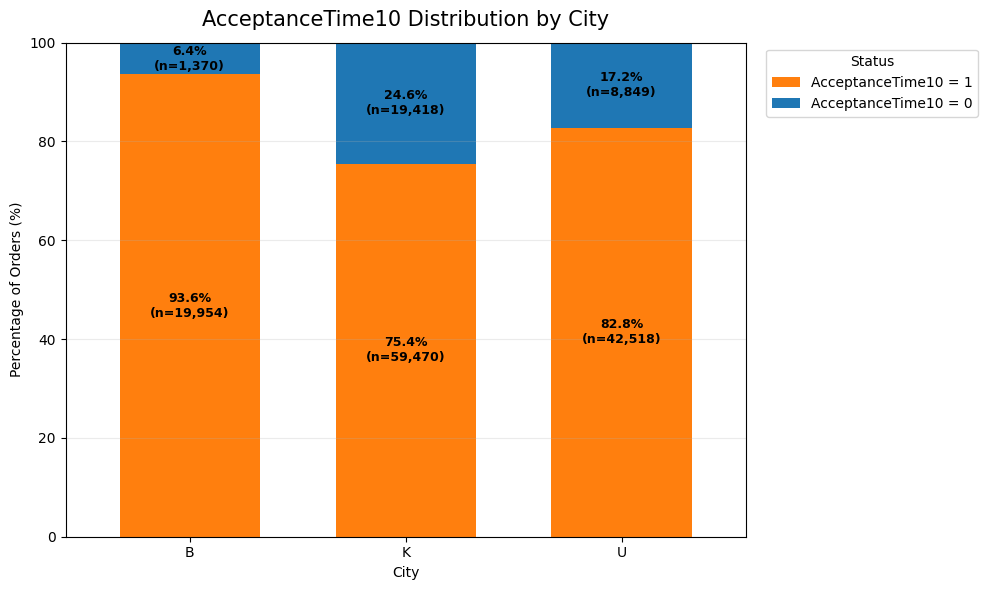

In [4]:
accept_valid = df[df["AcceptanceTime10"].notna()].copy()
accept_valid["AcceptanceTime10"] = accept_valid["AcceptanceTime10"].astype(int)

accept_city_counts, accept_city_pct, accept_city_summary = metric_city_tables(
    accept_valid, "AcceptanceTime10"
)

display(accept_city_summary)

plot_city_stacked(
    accept_city_counts,
    accept_city_pct,
    metric="AcceptanceTime10",
    title="AcceptanceTime10 Distribution by City"
)



CITY B


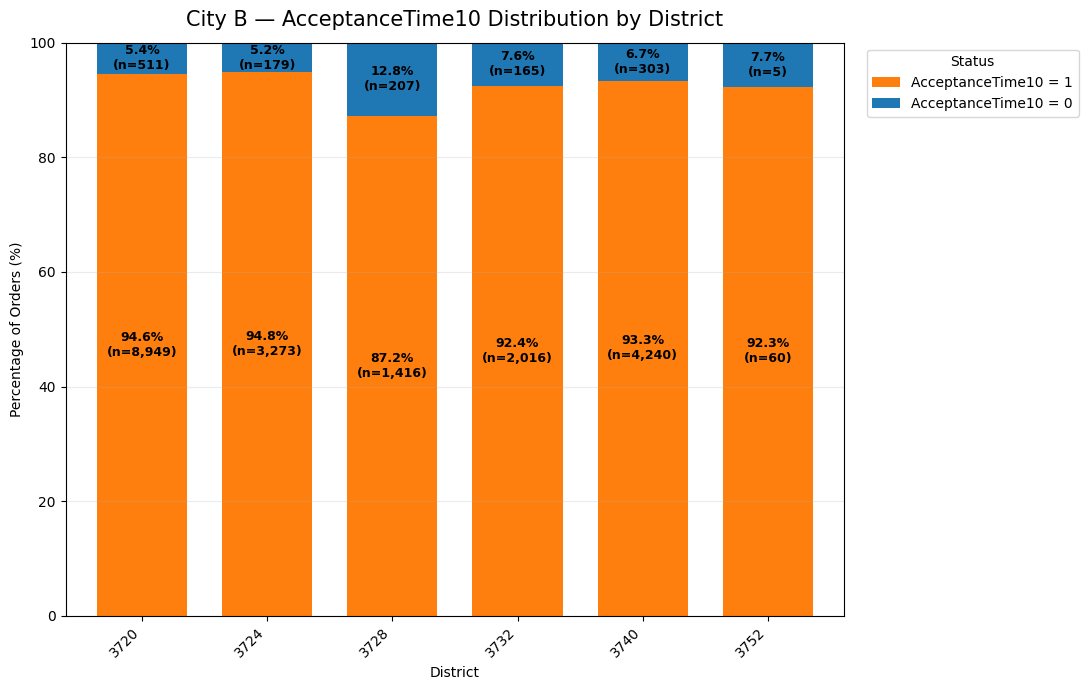

,Orders,AcceptanceTime10_0_Count,AcceptanceTime10_1_Count,AcceptanceTime10 = 0 (%),AcceptanceTime10 = 1 (%)
district,,,,,
3720,9460,511,8949,5.40,94.60
3724,3452,179,3273,5.19,94.81
3728,1623,207,1416,12.75,87.25
3732,2181,165,2016,7.57,92.43
3740,4543,303,4240,6.67,93.33
3752,65,5,60,7.69,92.31



CITY K


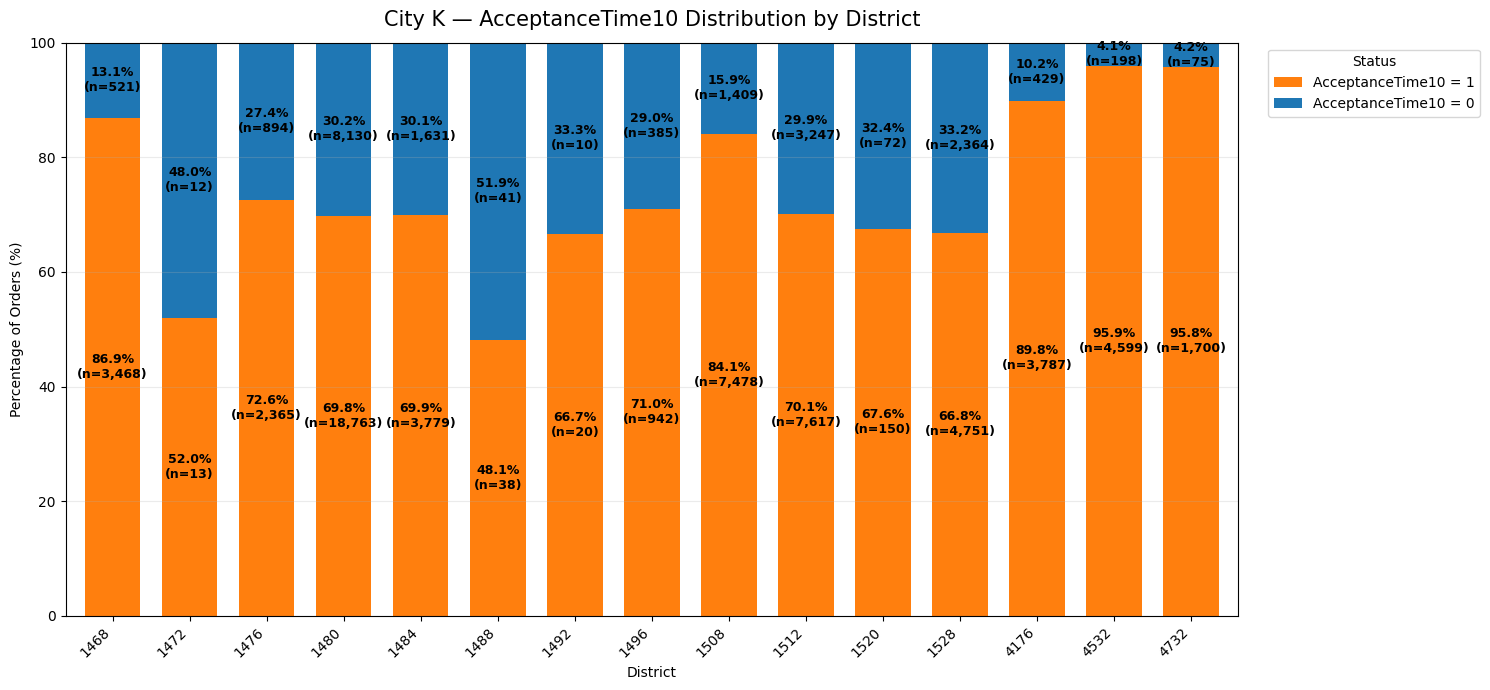

,Orders,AcceptanceTime10_0_Count,AcceptanceTime10_1_Count,AcceptanceTime10 = 0 (%),AcceptanceTime10 = 1 (%)
district,,,,,
1468,3989,521,3468,13.06,86.94
1472,25,12,13,48.00,52.00
1476,3259,894,2365,27.43,72.57
1480,26893,8130,18763,30.23,69.77
1484,5410,1631,3779,30.15,69.85
1488,79,41,38,51.90,48.10
1492,30,10,20,33.33,66.67
1496,1327,385,942,29.01,70.99
1508,8887,1409,7478,15.85,84.15



CITY U


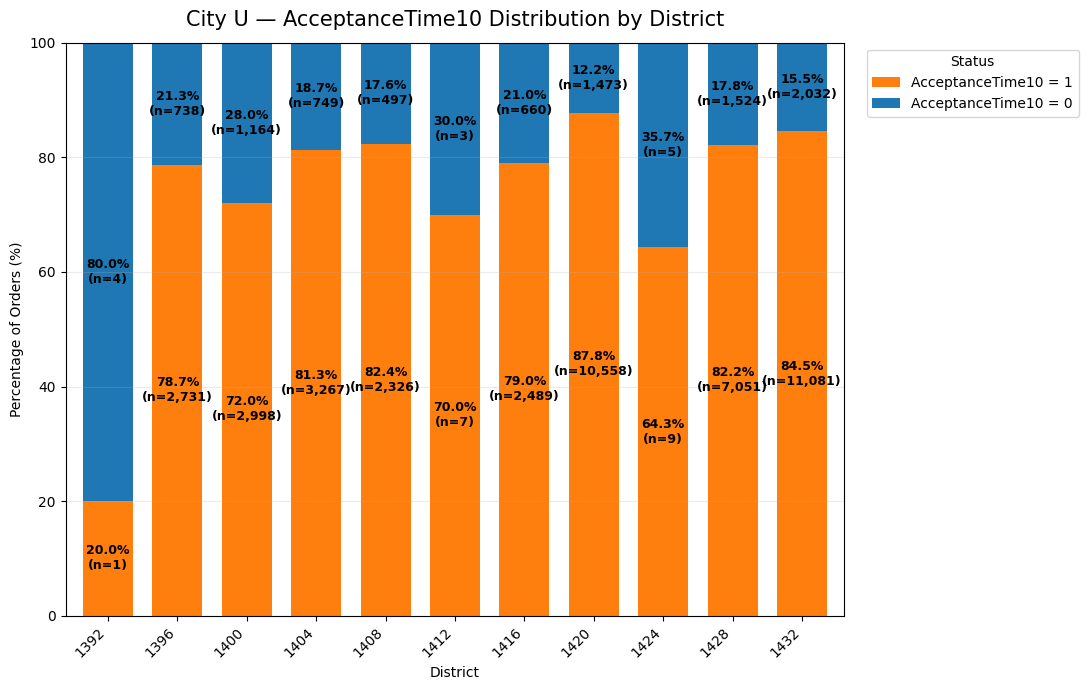

,Orders,AcceptanceTime10_0_Count,AcceptanceTime10_1_Count,AcceptanceTime10 = 0 (%),AcceptanceTime10 = 1 (%)
district,,,,,
1392,5,4,1,80.00,20.00
1396,3469,738,2731,21.27,78.73
1400,4162,1164,2998,27.97,72.03
1404,4016,749,3267,18.65,81.35
1408,2823,497,2326,17.61,82.39
1412,10,3,7,30.00,70.00
1416,3149,660,2489,20.96,79.04
1420,12031,1473,10558,12.24,87.76
1424,14,5,9,35.71,64.29


In [5]:
accept_district_counts, accept_district_pct, accept_district_summary = metric_district_tables(
    accept_valid, "AcceptanceTime10"
)

for city in ["B", "K", "U"]:
    print("\n" + "=" * 80)
    print(f"CITY {city}")
    print("=" * 80)

    display(
        plot_district_stacked(
            city,
            accept_district_counts,
            accept_district_summary,
            metric="AcceptanceTime10",
            title_prefix="AcceptanceTime10"
        )
    )


In [6]:
accept_ranking = (
    accept_district_summary
    .reset_index()
    .sort_values(
        ["order_city", "AcceptanceTime10 = 1 (%)"],
        ascending=[True, False]
    )
    .copy()
)

accept_ranking["Rank within City"] = (
    accept_ranking.groupby("order_city")["AcceptanceTime10 = 1 (%)"]
                  .rank(method="first", ascending=False)
                  .astype(int)
)

accept_ranking = accept_ranking[
    [
        "order_city",
        "Rank within City",
        "district",
        "Orders",
        "AcceptanceTime10_1_Count",
        "AcceptanceTime10_0_Count",
        "AcceptanceTime10 = 1 (%)",
        "AcceptanceTime10 = 0 (%)"
    ]
]

display(accept_ranking)


,order_city,Rank within City,district,Orders,AcceptanceTime10_1_Count,AcceptanceTime10_0_Count,AcceptanceTime10 = 1 (%),AcceptanceTime10 = 0 (%)
1,B,1,3724,3452,3273,179,94.81,5.19
0,B,2,3720,9460,8949,511,94.60,5.40
4,B,3,3740,4543,4240,303,93.33,6.67
3,B,4,3732,2181,2016,165,92.43,7.57
5,B,5,3752,65,60,5,92.31,7.69
2,B,6,3728,1623,1416,207,87.25,12.75
19,K,1,4532,4797,4599,198,95.87,4.13
20,K,2,4732,1775,1700,75,95.77,4.23
18,K,3,4176,4216,3787,429,89.82,10.18
6,K,4,1468,3989,3468,521,86.94,13.06


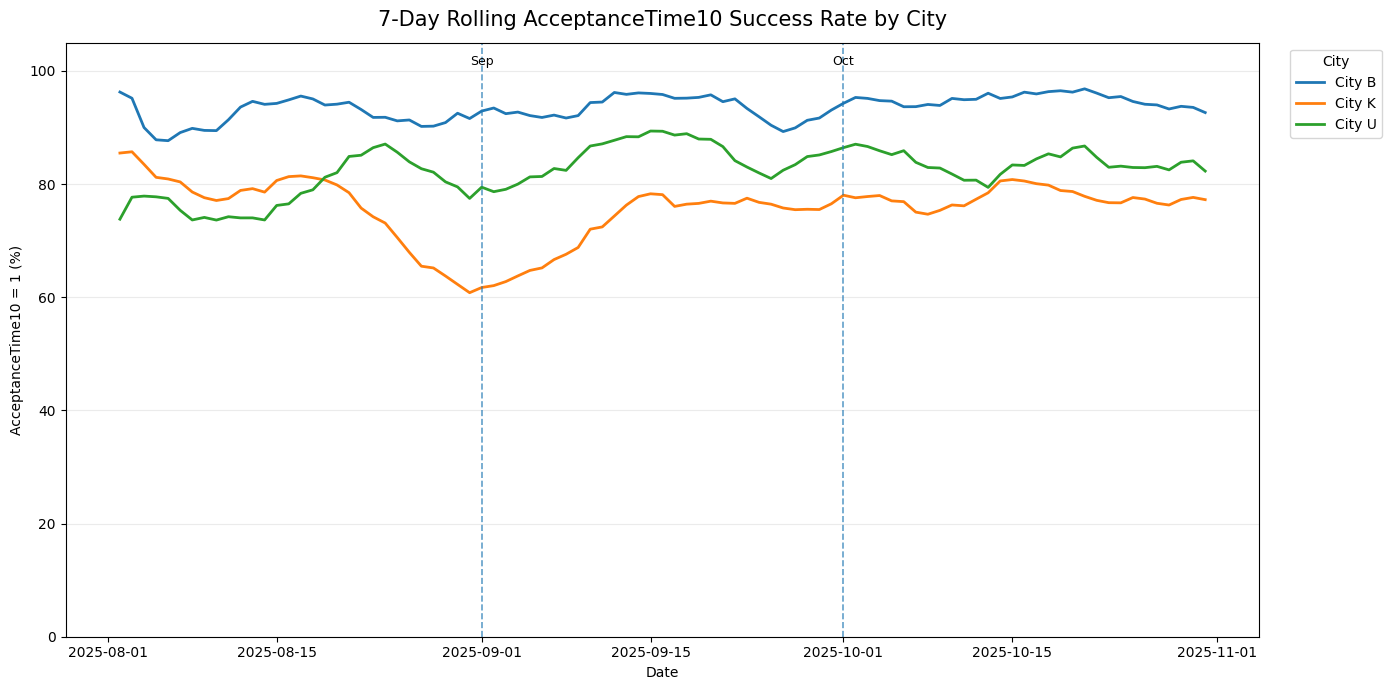

In [7]:
plot_city_trend(
    analysis_period,
    metric="AcceptanceTime10",
    title="7-Day Rolling AcceptanceTime10 Success Rate by City"
)


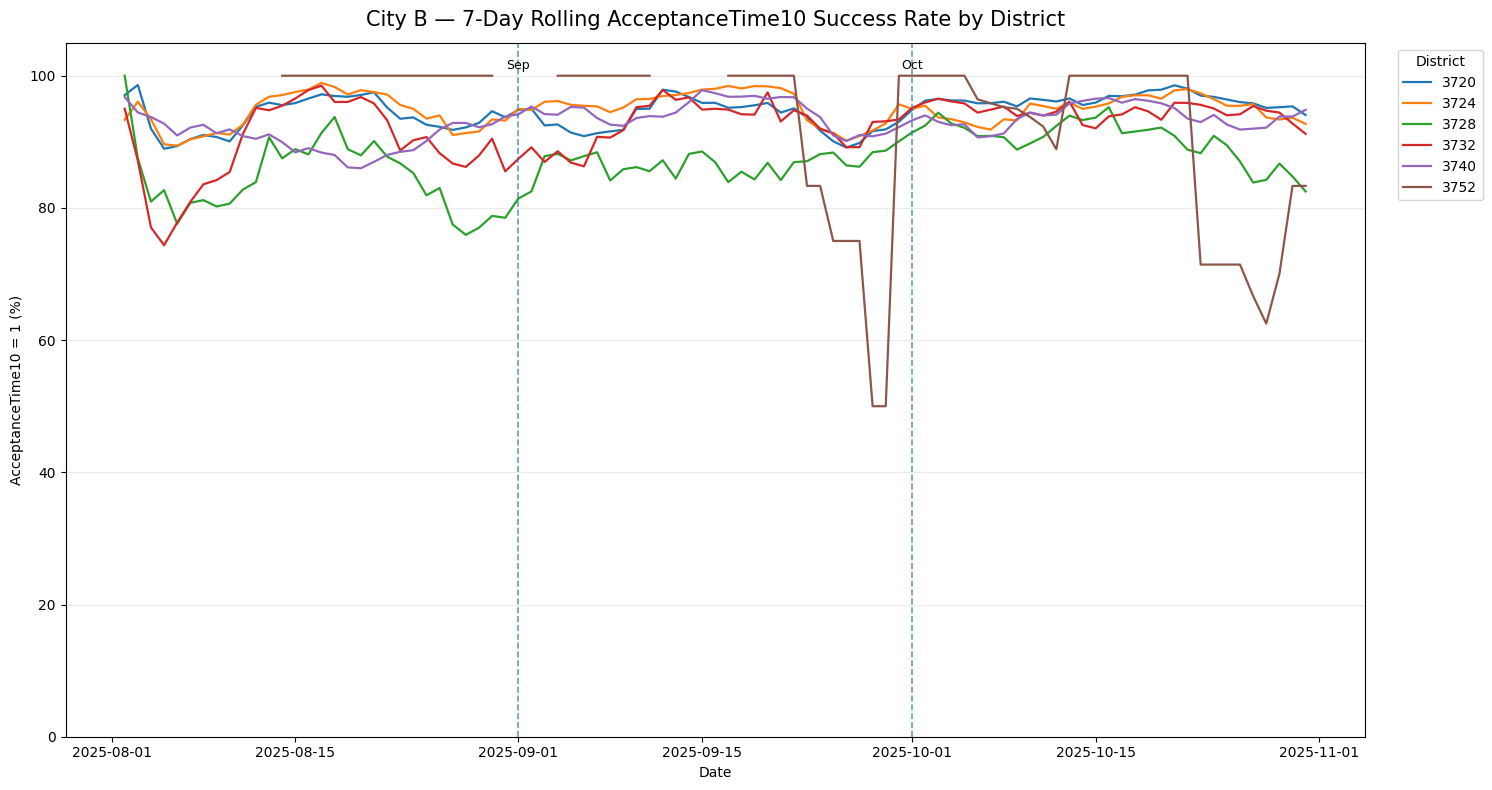

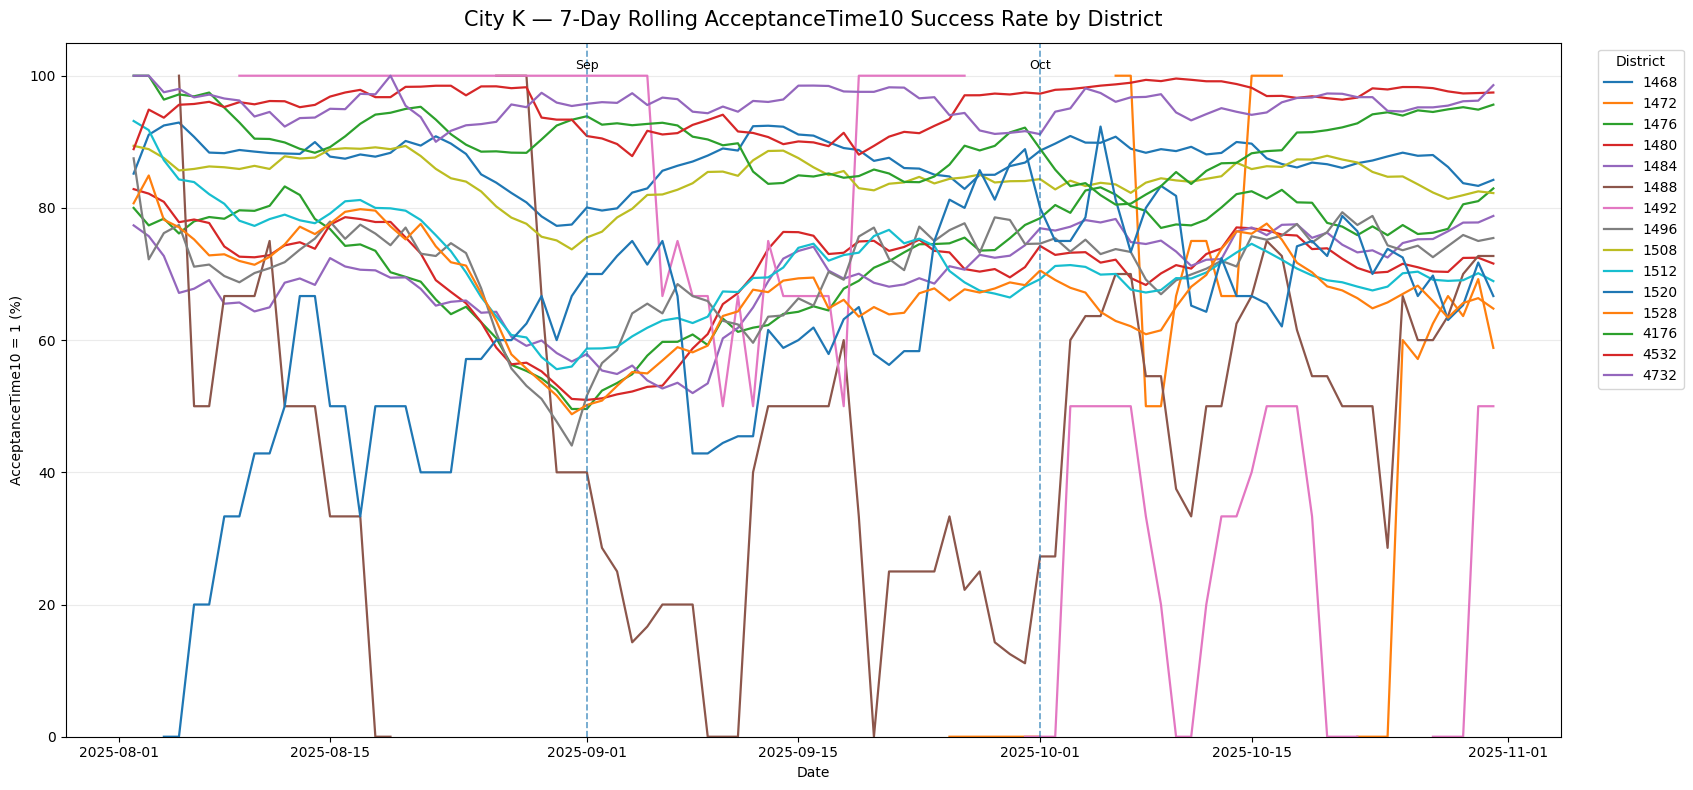

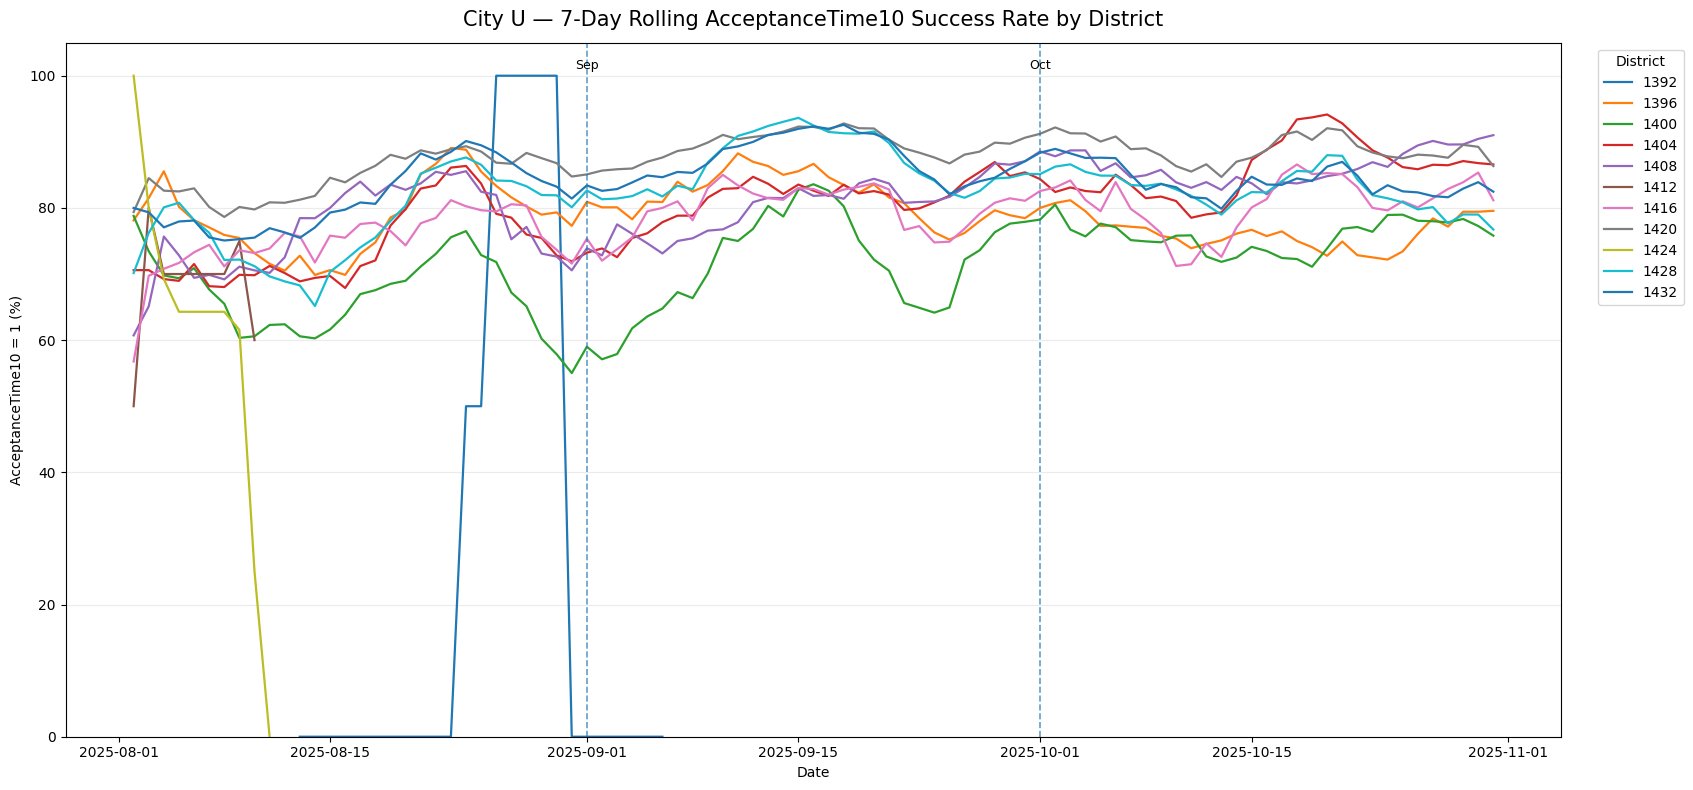

In [8]:
for city in ["B", "K", "U"]:
    plot_district_trends(
        analysis_period,
        city=city,
        metric="AcceptanceTime10",
        title_prefix="AcceptanceTime10"
    )


,order_city,AcceptanceTime10,Orders,BATR_Mean,BATR_Median,BATR_P90,BATR15 Success (%)
0,B,0,1370,27.38,22.00,41.00,12.63
1,B,1,19954,4.10,1.00,11.00,95.65
2,K,0,19418,24.29,20.00,37.00,17.79
3,K,1,59470,8.11,5.00,15.00,90.27
4,U,0,8849,26.00,21.00,39.00,14.56
5,U,1,42518,6.27,4.00,14.00,93.42


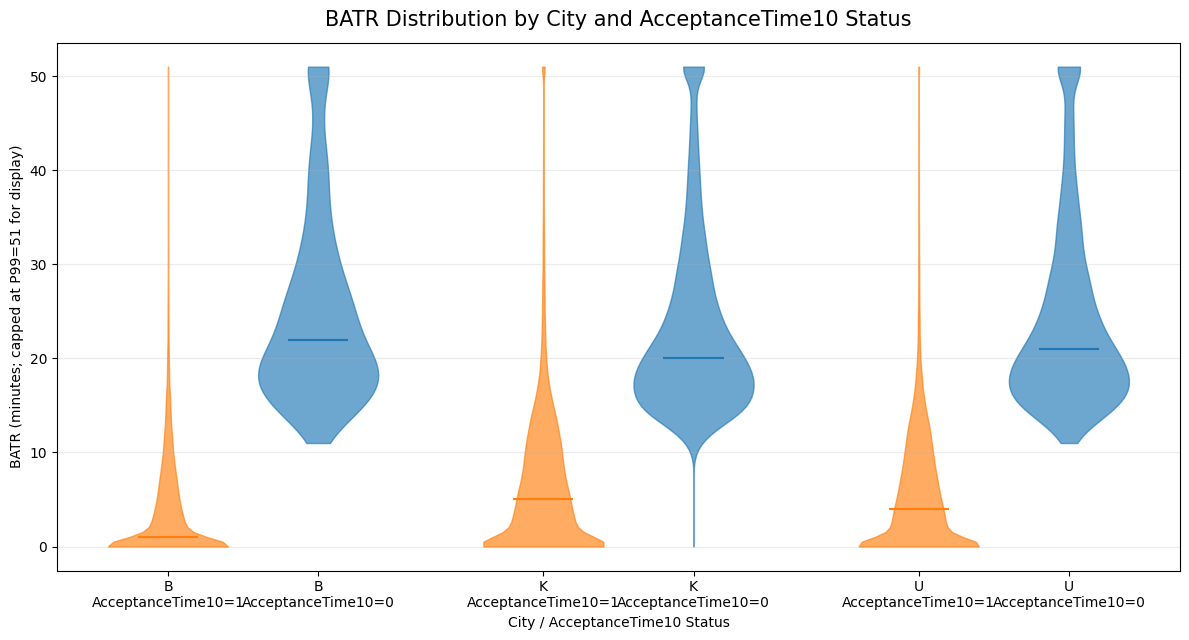

In [9]:
accept_batr = accept_valid[accept_valid["BATR_min"].notna()].copy()

ACCEPT_BATR_P99 = accept_batr["BATR_min"].quantile(0.99)
accept_batr["BATR_plot_min"] = accept_batr["BATR_min"].clip(upper=ACCEPT_BATR_P99)

accept_city_batr_summary = (
    accept_batr.groupby(["order_city", "AcceptanceTime10"])
               .agg(
                   Orders=("order_id", "count"),
                   BATR_Mean=("BATR_min", "mean"),
                   BATR_Median=("BATR_min", "median"),
                   BATR_P90=("BATR_min", lambda s: s.quantile(0.90)),
                   BATR15_Success=("BATR15", "mean")
               )
               .reset_index()
)

accept_city_batr_summary["BATR15 Success (%)"] = (
    accept_city_batr_summary["BATR15_Success"] * 100
)

display(
    accept_city_batr_summary[
        [
            "order_city", "AcceptanceTime10", "Orders",
            "BATR_Mean", "BATR_Median", "BATR_P90",
            "BATR15 Success (%)"
        ]
    ]
)

fig, ax = plt.subplots(figsize=(12, 6.5))

positions, labels = [], []
pos = 1

for city in ["B", "K", "U"]:
    for status in [1, 0]:
        vals = accept_batr.loc[
            (accept_batr["order_city"] == city)
            & (accept_batr["AcceptanceTime10"] == status),
            "BATR_plot_min"
        ].dropna().values

        if len(vals) >= 2 and np.nanstd(vals) > 0:
            parts = ax.violinplot(
                vals,
                positions=[pos],
                widths=0.8,
                showmeans=False,
                showmedians=True,
                showextrema=False
            )
            color_violin(parts, COLOR_1 if status == 1 else COLOR_0)
        elif len(vals) >= 1:
            ax.scatter(
                [pos],
                [np.nanmedian(vals)],
                color=COLOR_1 if status == 1 else COLOR_0
            )

        positions.append(pos)
        labels.append(f"{city}\nAcceptanceTime10={status}")
        pos += 1

    pos += 0.5

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_title(
    "BATR Distribution by City and AcceptanceTime10 Status",
    fontsize=15,
    pad=12
)
ax.set_xlabel("City / AcceptanceTime10 Status")
ax.set_ylabel(
    f"BATR (minutes; capped at P99={ACCEPT_BATR_P99:.0f} for display)"
)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()



CITY B — ACCEPTANCE / BATR VIOLIN


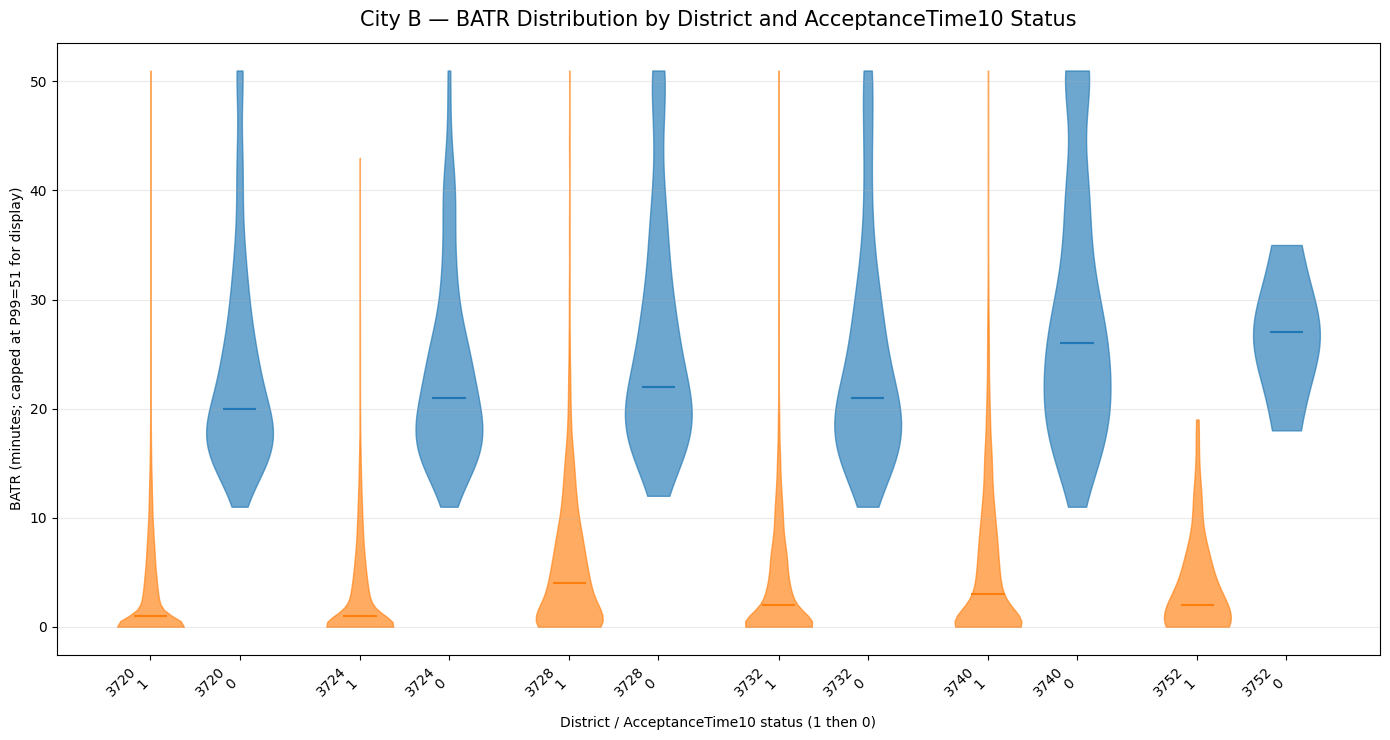

,order_city,district,AcceptanceTime10,Orders,BATR_Mean,BATR_Median,BATR_P90,BATR15 Success (%)
1,B,3720,1,8949,3.14,1.00,9.00,97.32
0,B,3720,0,511,24.45,20.00,35.00,15.85
3,B,3724,1,3273,2.97,1.00,9.00,97.56
2,B,3724,0,179,23.19,21.00,37.00,13.97
5,B,3728,1,1416,6.27,4.00,13.00,93.71
4,B,3728,0,207,27.57,22.00,42.80,8.70
7,B,3732,1,2016,3.63,2.00,10.00,96.97
6,B,3732,0,165,25.33,21.00,40.20,14.55
9,B,3740,1,4240,6.52,3.00,15.00,90.66
8,B,3740,0,303,35.82,26.00,50.00,8.25



CITY K — ACCEPTANCE / BATR VIOLIN


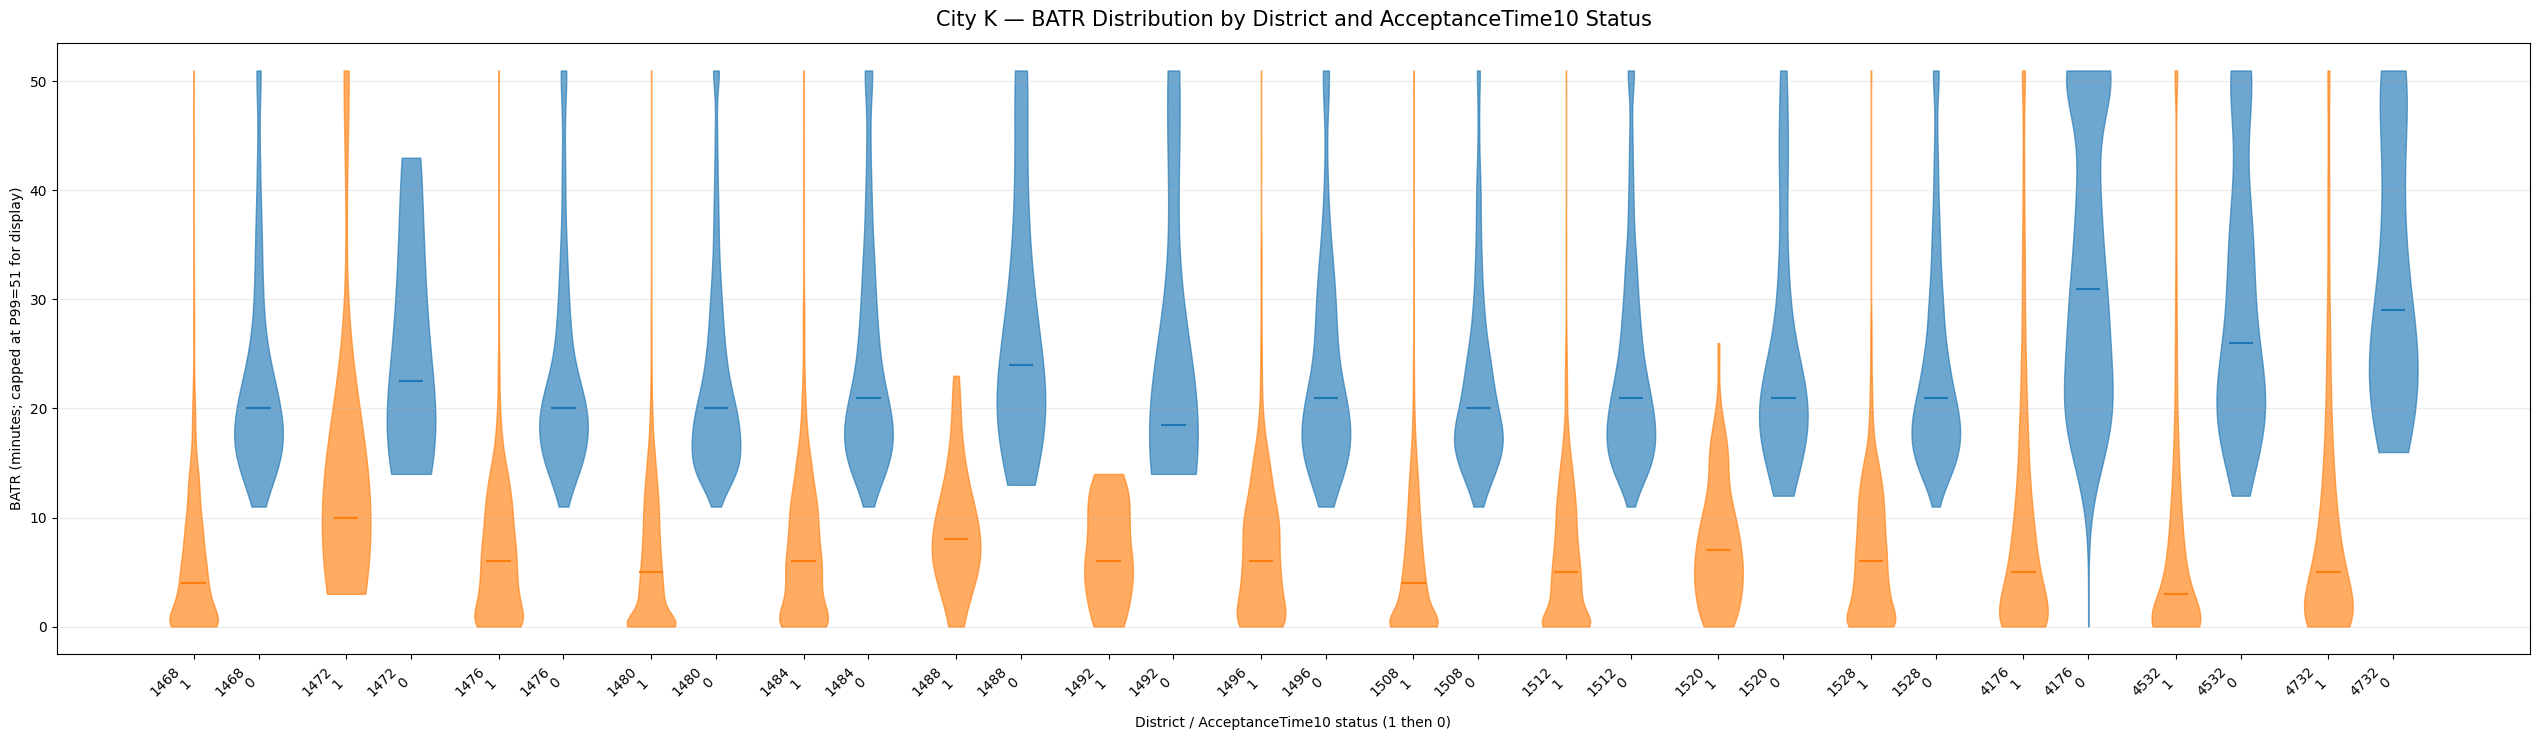

,order_city,district,AcceptanceTime10,Orders,BATR_Mean,BATR_Median,BATR_P90,BATR15 Success (%)
13,K,1468,1,3468,5.90,4.00,14.00,92.73
12,K,1468,0,521,22.82,20.00,35.00,19.39
15,K,1472,1,13,13.92,10.00,17.80,69.23
14,K,1472,0,12,25.42,22.50,41.20,8.33
17,K,1476,1,2365,16.99,6.00,15.00,92.47
16,K,1476,0,894,24.52,20.00,36.00,15.66
19,K,1480,1,18763,8.29,5.00,15.00,91.35
18,K,1480,0,8130,22.95,20.00,35.00,21.34
21,K,1484,1,3779,7.39,6.00,15.00,90.08
20,K,1484,0,1631,25.14,21.00,39.00,15.70



CITY U — ACCEPTANCE / BATR VIOLIN


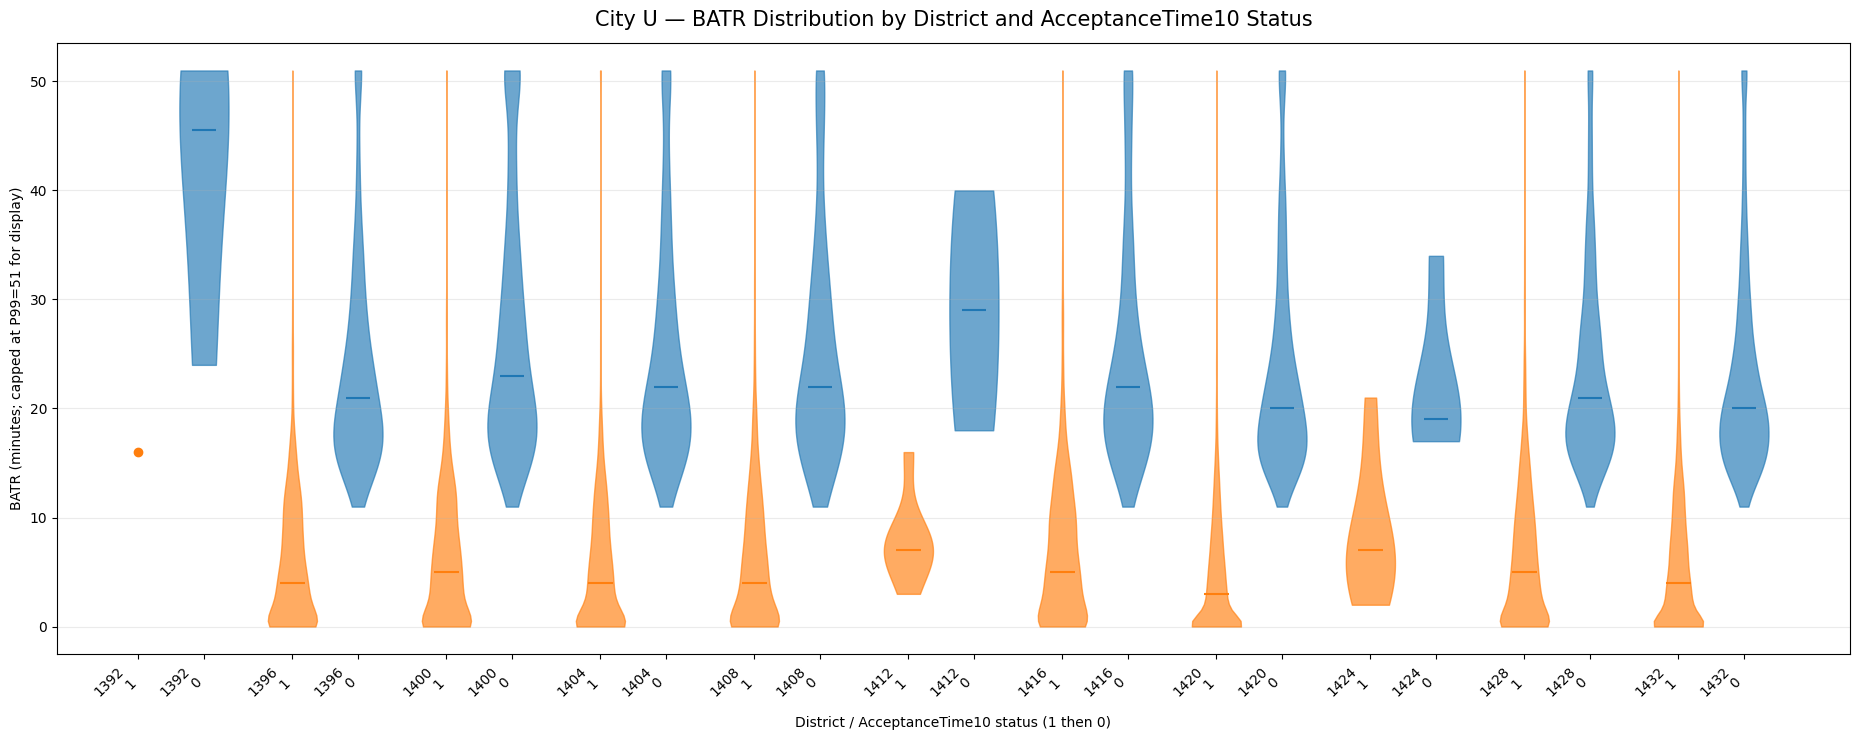

,order_city,district,AcceptanceTime10,Orders,BATR_Mean,BATR_Median,BATR_P90,BATR15 Success (%)
43,U,1392,1,1,16.00,16.00,16.00,0.00
42,U,1392,0,4,45.25,48.50,59.10,0.00
45,U,1396,1,2731,5.93,4.00,14.00,93.59
44,U,1396,0,738,24.64,21.00,36.30,15.72
47,U,1400,1,2998,6.52,5.00,14.00,92.66
46,U,1400,0,1164,34.24,23.00,48.70,11.00
49,U,1404,1,3267,6.48,4.00,13.00,93.97
48,U,1404,0,749,25.74,22.00,42.00,12.42
51,U,1408,1,2326,6.26,4.00,15.00,91.62
50,U,1408,0,497,25.90,22.00,42.00,14.49


In [10]:
accept_district_batr_summary = (
    accept_batr.groupby(["order_city", "district", "AcceptanceTime10"])
               .agg(
                   Orders=("order_id", "count"),
                   BATR_Mean=("BATR_min", "mean"),
                   BATR_Median=("BATR_min", "median"),
                   BATR_P90=("BATR_min", lambda s: s.quantile(0.90)),
                   BATR15_Success=("BATR15", "mean")
               )
               .reset_index()
)

accept_district_batr_summary["BATR15 Success (%)"] = (
    accept_district_batr_summary["BATR15_Success"] * 100
)


def plot_acceptance_district_violins(city):
    city_data = accept_batr[accept_batr["order_city"] == city].copy()
    districts = sorted(city_data["district"].dropna().unique())

    fig_width = max(14, len(districts) * 1.7)
    fig, ax = plt.subplots(figsize=(fig_width, 7.5))

    positions, labels = [], []
    pos = 1

    for district in districts:
        for status in [1, 0]:
            vals = city_data.loc[
                (city_data["district"] == district)
                & (city_data["AcceptanceTime10"] == status),
                "BATR_plot_min"
            ].dropna().values

            if len(vals) >= 2 and np.nanstd(vals) > 0:
                parts = ax.violinplot(
                    vals,
                    positions=[pos],
                    widths=0.75,
                    showmeans=False,
                    showmedians=True,
                    showextrema=False
                )
                color_violin(parts, COLOR_1 if status == 1 else COLOR_0)
            elif len(vals) >= 1:
                ax.scatter(
                    [pos],
                    [np.nanmedian(vals)],
                    color=COLOR_1 if status == 1 else COLOR_0
                )

            positions.append(pos)
            labels.append(f"{int(district)}\n{status}")
            pos += 1

        pos += 0.35

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title(
        f"City {city} — BATR Distribution by District and AcceptanceTime10 Status",
        fontsize=15,
        pad=12
    )
    ax.set_xlabel("District / AcceptanceTime10 status (1 then 0)")
    ax.set_ylabel(
        f"BATR (minutes; capped at P99={ACCEPT_BATR_P99:.0f} for display)"
    )
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

    return (
        accept_district_batr_summary[
            accept_district_batr_summary["order_city"] == city
        ]
        .sort_values(
            ["district", "AcceptanceTime10"],
            ascending=[True, False]
        )
        [
            [
                "order_city", "district", "AcceptanceTime10", "Orders",
                "BATR_Mean", "BATR_Median", "BATR_P90",
                "BATR15 Success (%)"
            ]
        ]
    )


for city in ["B", "K", "U"]:
    print("\n" + "=" * 80)
    print(f"CITY {city} — ACCEPTANCE / BATR VIOLIN")
    print("=" * 80)
    display(plot_acceptance_district_violins(city))


,Orders,ArrivalTime5 = 0 (%),ArrivalTime5 = 1 (%)
order_city,,,
B,21324,22.03,77.97
K,78888,37.24,62.76
U,51367,31.37,68.63


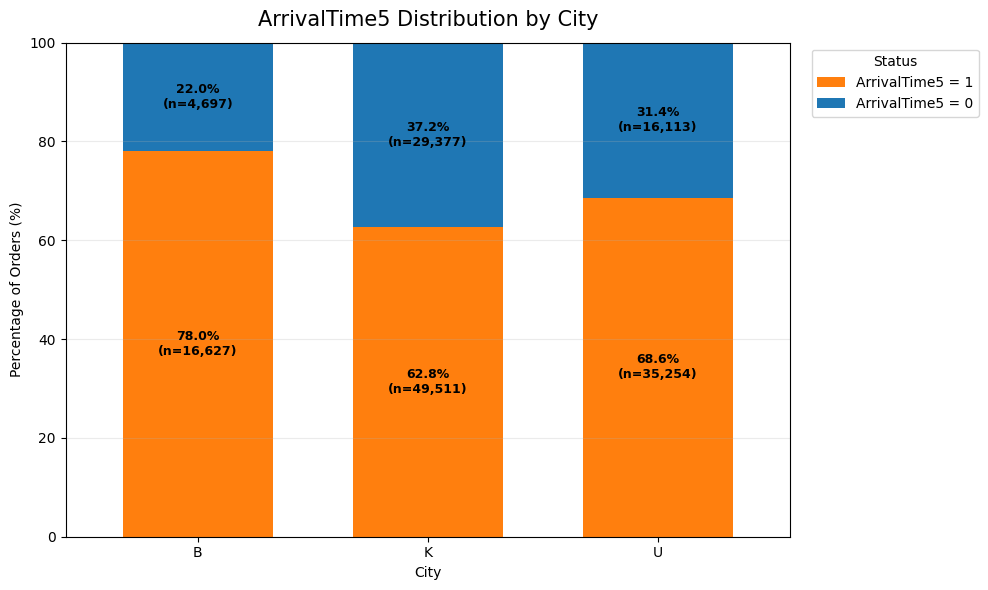

In [11]:
arrival_valid = df[df["ArrivalTime5"].notna()].copy()
arrival_valid["ArrivalTime5"] = arrival_valid["ArrivalTime5"].astype(int)

arrival_city_counts, arrival_city_pct, arrival_city_summary = metric_city_tables(
    arrival_valid, "ArrivalTime5"
)

display(arrival_city_summary)

plot_city_stacked(
    arrival_city_counts,
    arrival_city_pct,
    metric="ArrivalTime5",
    title="ArrivalTime5 Distribution by City"
)



CITY B


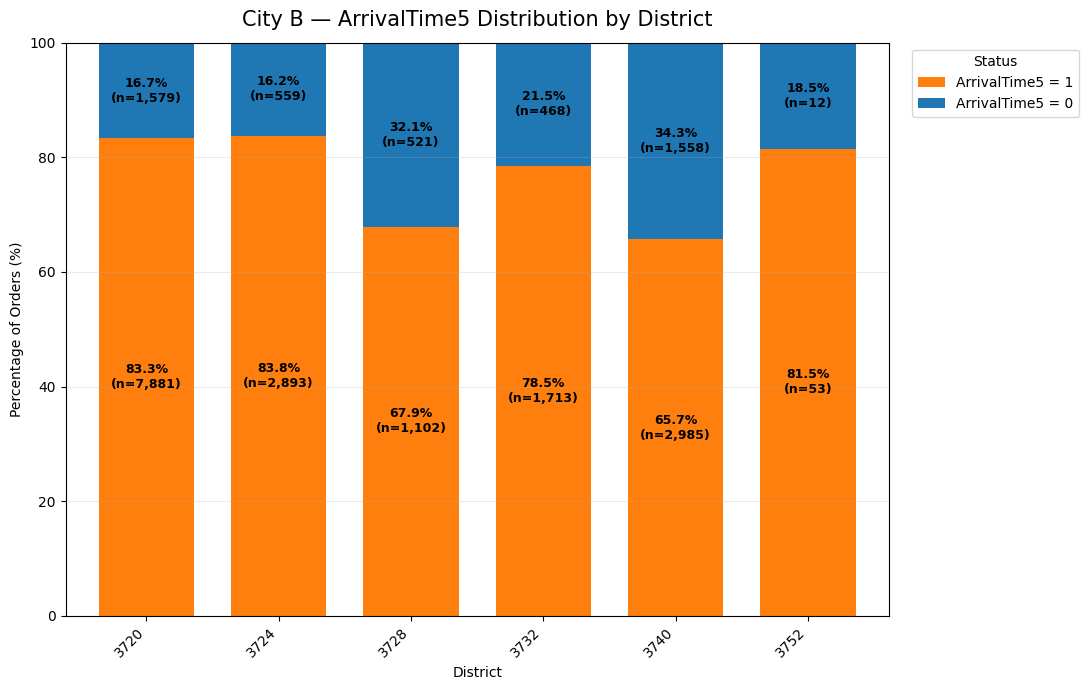

,Orders,ArrivalTime5_0_Count,ArrivalTime5_1_Count,ArrivalTime5 = 0 (%),ArrivalTime5 = 1 (%)
district,,,,,
3720,9460,1579,7881,16.69,83.31
3724,3452,559,2893,16.19,83.81
3728,1623,521,1102,32.10,67.90
3732,2181,468,1713,21.46,78.54
3740,4543,1558,2985,34.29,65.71
3752,65,12,53,18.46,81.54



CITY K


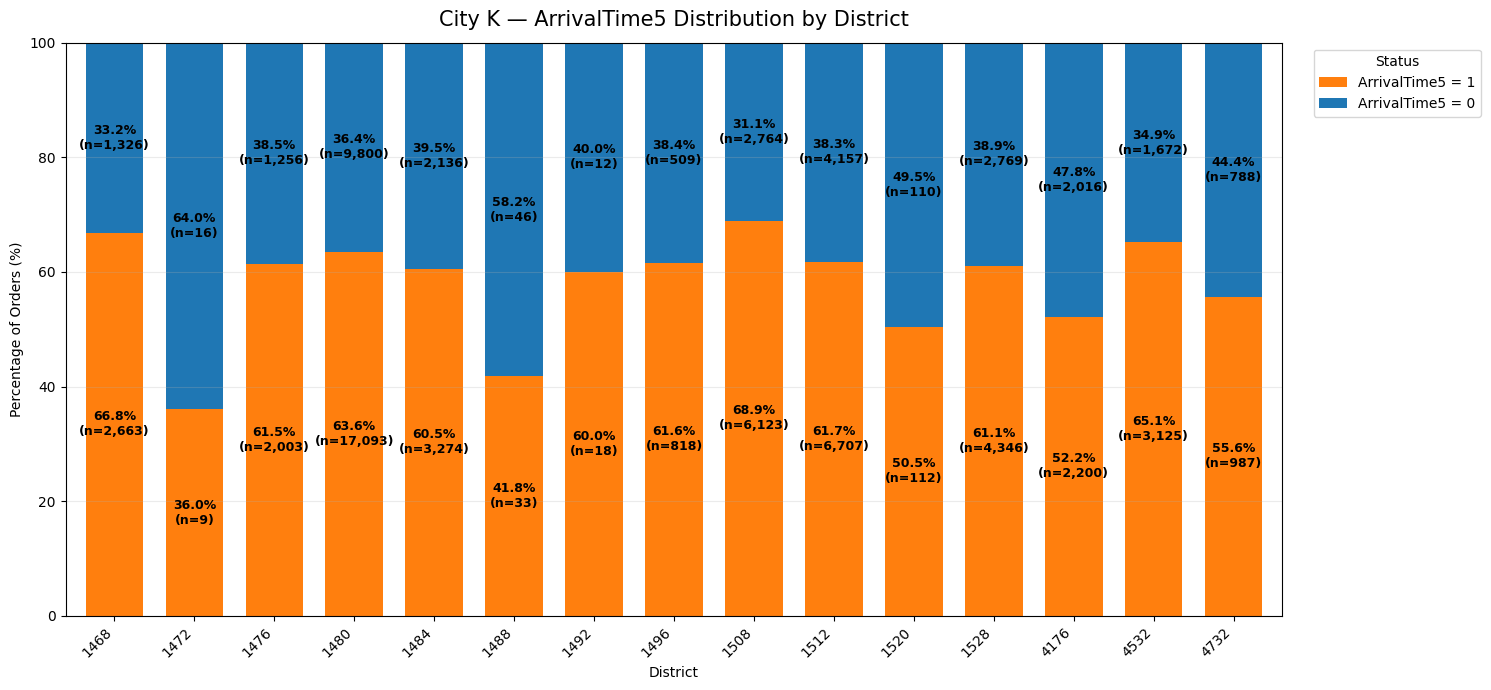

,Orders,ArrivalTime5_0_Count,ArrivalTime5_1_Count,ArrivalTime5 = 0 (%),ArrivalTime5 = 1 (%)
district,,,,,
1468,3989,1326,2663,33.24,66.76
1472,25,16,9,64.00,36.00
1476,3259,1256,2003,38.54,61.46
1480,26893,9800,17093,36.44,63.56
1484,5410,2136,3274,39.48,60.52
1488,79,46,33,58.23,41.77
1492,30,12,18,40.00,60.00
1496,1327,509,818,38.36,61.64
1508,8887,2764,6123,31.10,68.90



CITY U


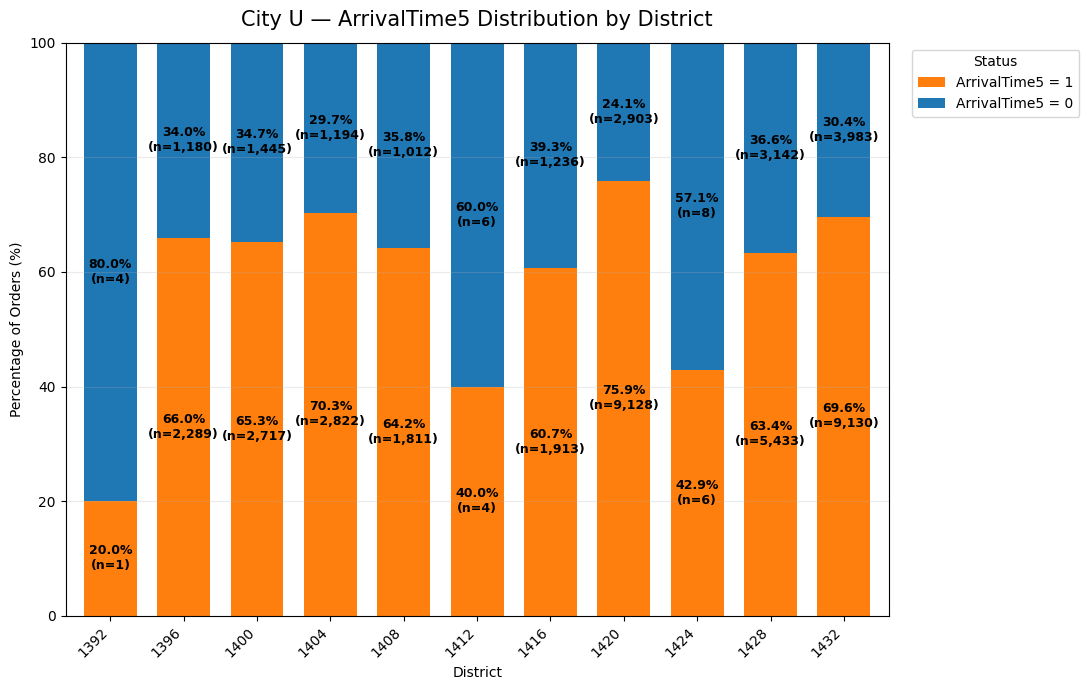

,Orders,ArrivalTime5_0_Count,ArrivalTime5_1_Count,ArrivalTime5 = 0 (%),ArrivalTime5 = 1 (%)
district,,,,,
1392,5,4,1,80.00,20.00
1396,3469,1180,2289,34.02,65.98
1400,4162,1445,2717,34.72,65.28
1404,4016,1194,2822,29.73,70.27
1408,2823,1012,1811,35.85,64.15
1412,10,6,4,60.00,40.00
1416,3149,1236,1913,39.25,60.75
1420,12031,2903,9128,24.13,75.87
1424,14,8,6,57.14,42.86


In [12]:
arrival_district_counts, arrival_district_pct, arrival_district_summary = metric_district_tables(
    arrival_valid, "ArrivalTime5"
)

for city in ["B", "K", "U"]:
    print("\n" + "=" * 80)
    print(f"CITY {city}")
    print("=" * 80)

    display(
        plot_district_stacked(
            city,
            arrival_district_counts,
            arrival_district_summary,
            metric="ArrivalTime5",
            title_prefix="ArrivalTime5"
        )
    )


In [13]:
arrival_ranking = (
    arrival_district_summary
    .reset_index()
    .sort_values(
        ["order_city", "ArrivalTime5 = 1 (%)"],
        ascending=[True, False]
    )
    .copy()
)

arrival_ranking["Rank within City"] = (
    arrival_ranking.groupby("order_city")["ArrivalTime5 = 1 (%)"]
                   .rank(method="first", ascending=False)
                   .astype(int)
)

arrival_ranking = arrival_ranking[
    [
        "order_city",
        "Rank within City",
        "district",
        "Orders",
        "ArrivalTime5_1_Count",
        "ArrivalTime5_0_Count",
        "ArrivalTime5 = 1 (%)",
        "ArrivalTime5 = 0 (%)"
    ]
]

display(arrival_ranking)


,order_city,Rank within City,district,Orders,ArrivalTime5_1_Count,ArrivalTime5_0_Count,ArrivalTime5 = 1 (%),ArrivalTime5 = 0 (%)
1,B,1,3724,3452,2893,559,83.81,16.19
0,B,2,3720,9460,7881,1579,83.31,16.69
5,B,3,3752,65,53,12,81.54,18.46
3,B,4,3732,2181,1713,468,78.54,21.46
2,B,5,3728,1623,1102,521,67.90,32.10
4,B,6,3740,4543,2985,1558,65.71,34.29
14,K,1,1508,8887,6123,2764,68.90,31.10
6,K,2,1468,3989,2663,1326,66.76,33.24
19,K,3,4532,4797,3125,1672,65.14,34.86
9,K,4,1480,26893,17093,9800,63.56,36.44


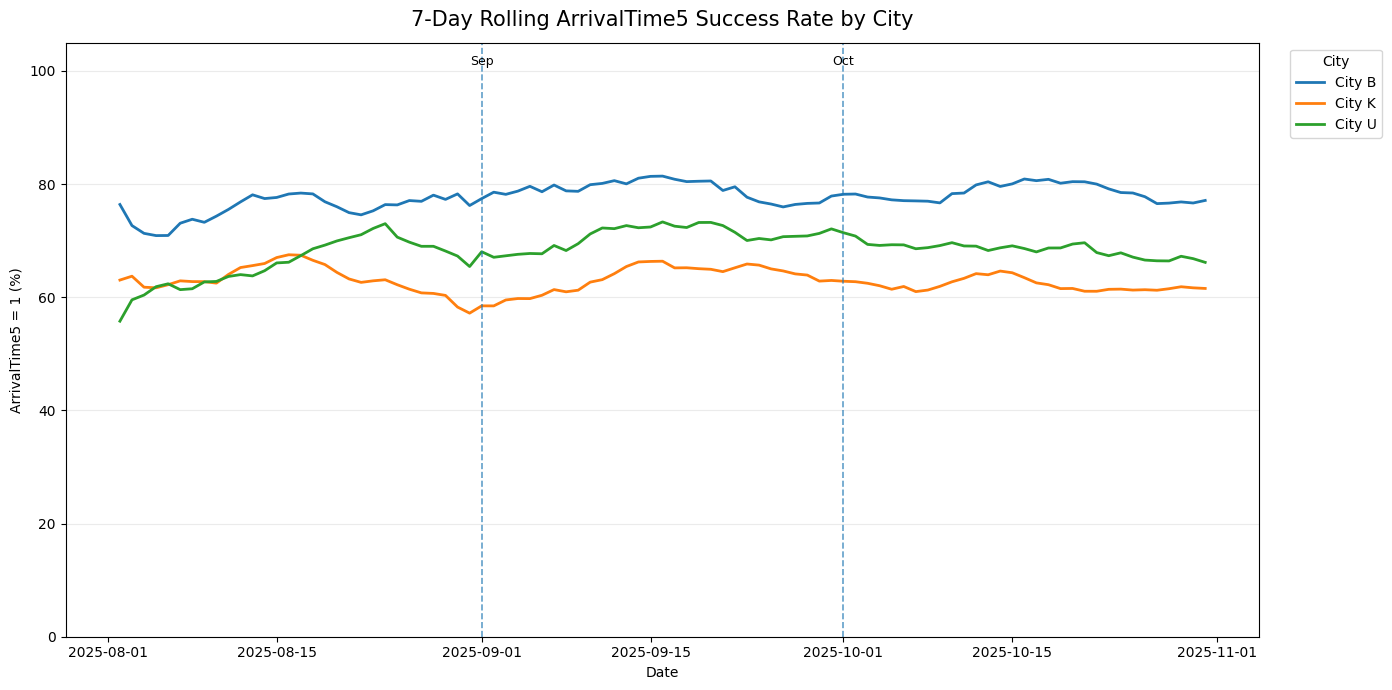

In [14]:
plot_city_trend(
    analysis_period,
    metric="ArrivalTime5",
    title="7-Day Rolling ArrivalTime5 Success Rate by City"
)


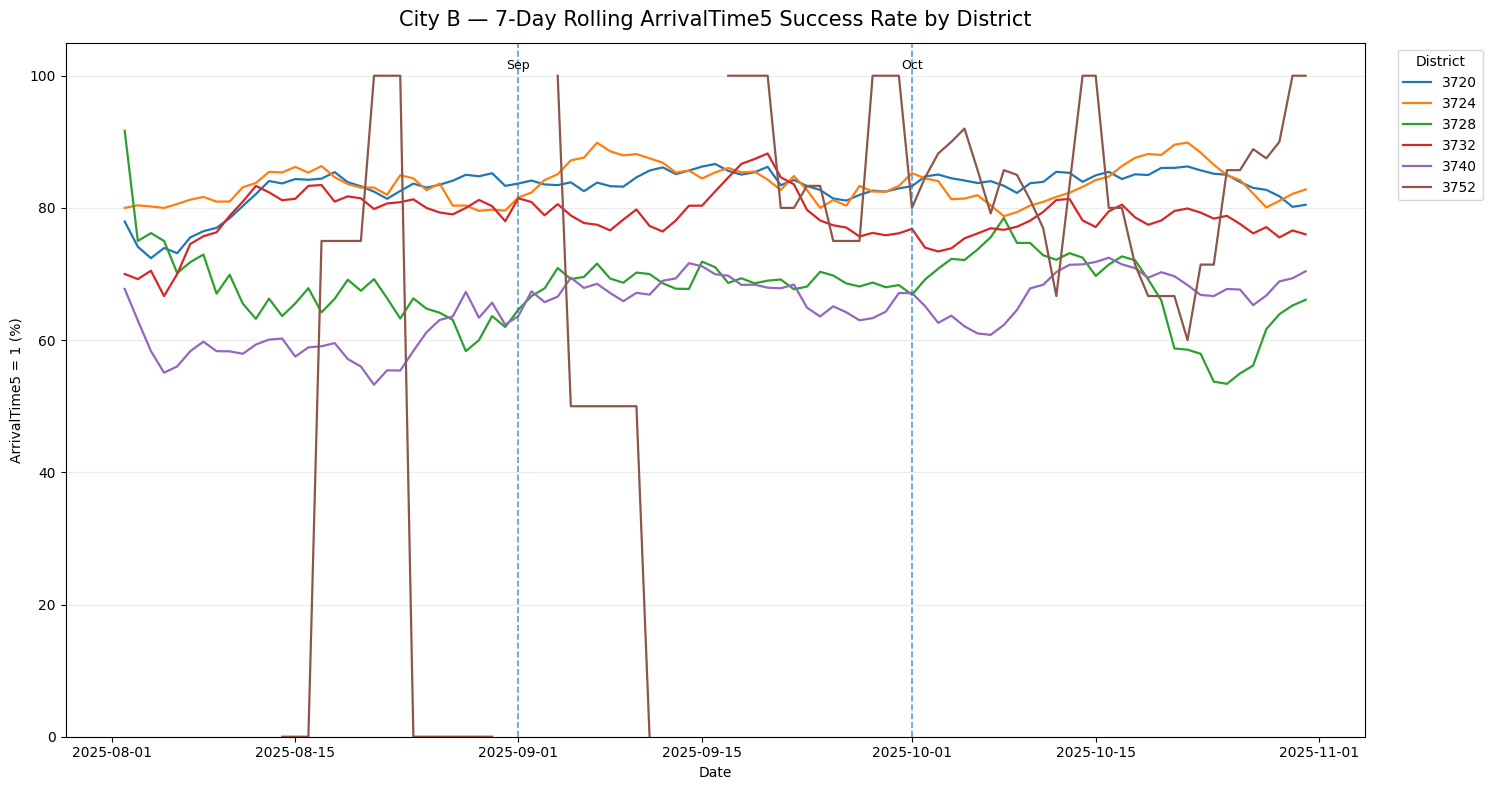

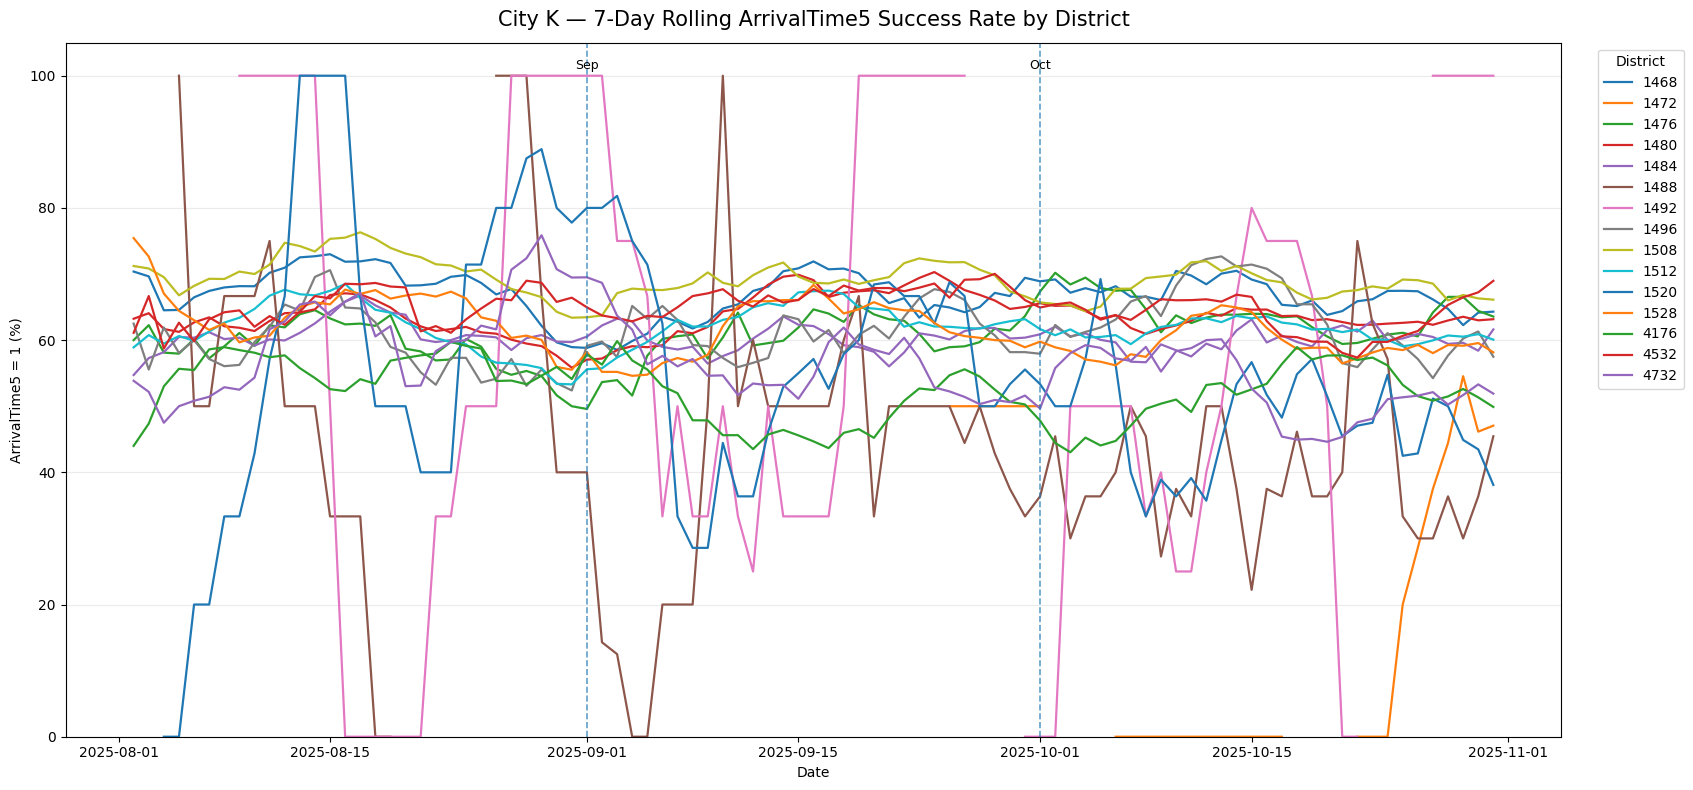

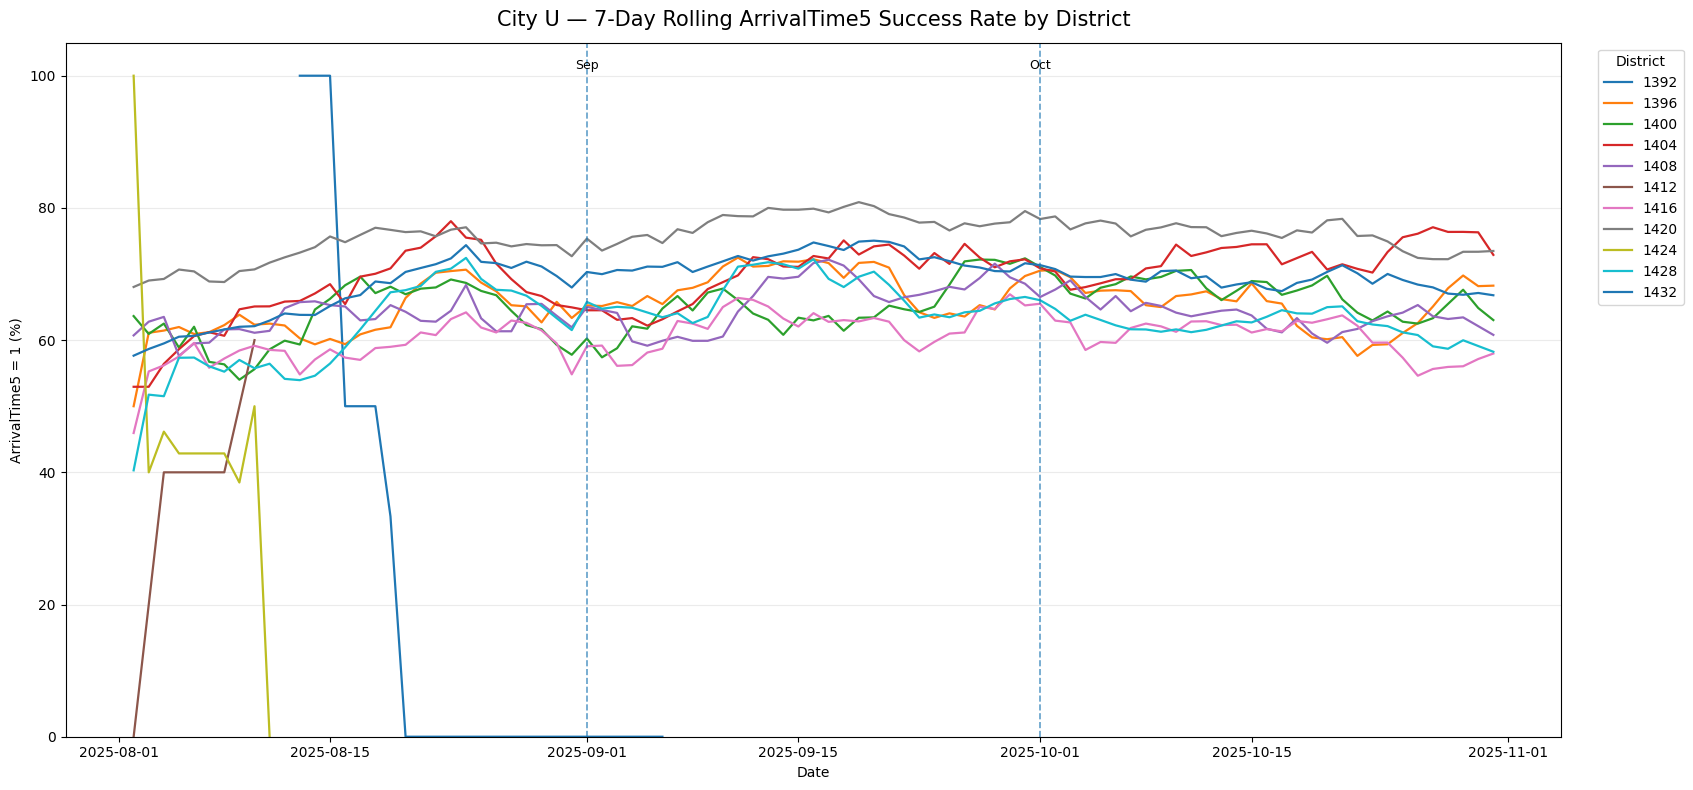

In [15]:
for city in ["B", "K", "U"]:
    plot_district_trends(
        analysis_period,
        city=city,
        metric="ArrivalTime5",
        title_prefix="ArrivalTime5"
    )


,order_city,ArrivalTime5,Orders,BATR_Mean,BATR_Median,BATR_P90,BATR15 Success (%)
0,B,0,4697,16.14,11.00,26.00,68.28
1,B,1,16627,2.62,0.00,6.00,96.54
2,K,0,29377,22.17,17.00,34.00,44.23
3,K,1,49511,6.11,3.00,16.00,89.16
4,U,0,16113,19.50,15.00,32.00,53.09
5,U,1,35254,5.18,3.00,14.00,92.05


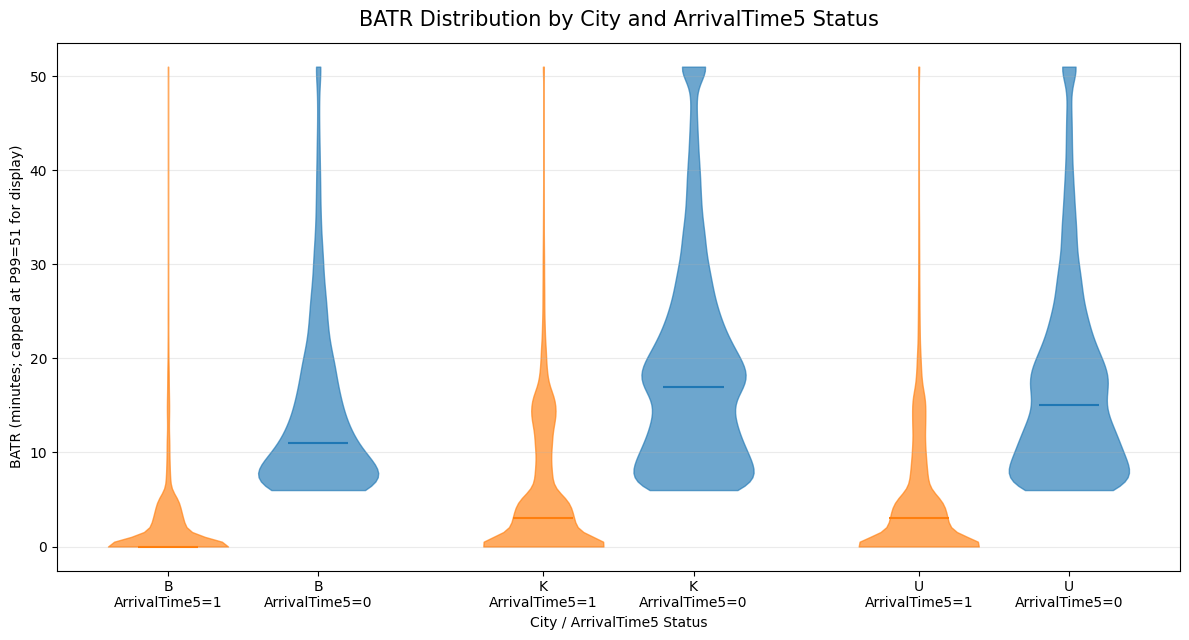

In [16]:
arrival_batr = arrival_valid[arrival_valid["BATR_min"].notna()].copy()

ARRIVAL_BATR_P99 = arrival_batr["BATR_min"].quantile(0.99)
arrival_batr["BATR_plot_min"] = arrival_batr["BATR_min"].clip(
    upper=ARRIVAL_BATR_P99
)

arrival_city_batr_summary = (
    arrival_batr.groupby(["order_city", "ArrivalTime5"])
                .agg(
                    Orders=("order_id", "count"),
                    BATR_Mean=("BATR_min", "mean"),
                    BATR_Median=("BATR_min", "median"),
                    BATR_P90=("BATR_min", lambda s: s.quantile(0.90)),
                    BATR15_Success=("BATR15", "mean")
                )
                .reset_index()
)

arrival_city_batr_summary["BATR15 Success (%)"] = (
    arrival_city_batr_summary["BATR15_Success"] * 100
)

display(
    arrival_city_batr_summary[
        [
            "order_city", "ArrivalTime5", "Orders",
            "BATR_Mean", "BATR_Median", "BATR_P90",
            "BATR15 Success (%)"
        ]
    ]
)

fig, ax = plt.subplots(figsize=(12, 6.5))

positions, labels = [], []
pos = 1

for city in ["B", "K", "U"]:
    for status in [1, 0]:
        vals = arrival_batr.loc[
            (arrival_batr["order_city"] == city)
            & (arrival_batr["ArrivalTime5"] == status),
            "BATR_plot_min"
        ].dropna().values

        if len(vals) >= 2 and np.nanstd(vals) > 0:
            parts = ax.violinplot(
                vals,
                positions=[pos],
                widths=0.8,
                showmeans=False,
                showmedians=True,
                showextrema=False
            )
            color_violin(parts, COLOR_1 if status == 1 else COLOR_0)
        elif len(vals) >= 1:
            ax.scatter(
                [pos],
                [np.nanmedian(vals)],
                color=COLOR_1 if status == 1 else COLOR_0
            )

        positions.append(pos)
        labels.append(f"{city}\nArrivalTime5={status}")
        pos += 1

    pos += 0.5

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_title(
    "BATR Distribution by City and ArrivalTime5 Status",
    fontsize=15,
    pad=12
)
ax.set_xlabel("City / ArrivalTime5 Status")
ax.set_ylabel(
    f"BATR (minutes; capped at P99={ARRIVAL_BATR_P99:.0f} for display)"
)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()



CITY B — ARRIVAL / BATR VIOLIN


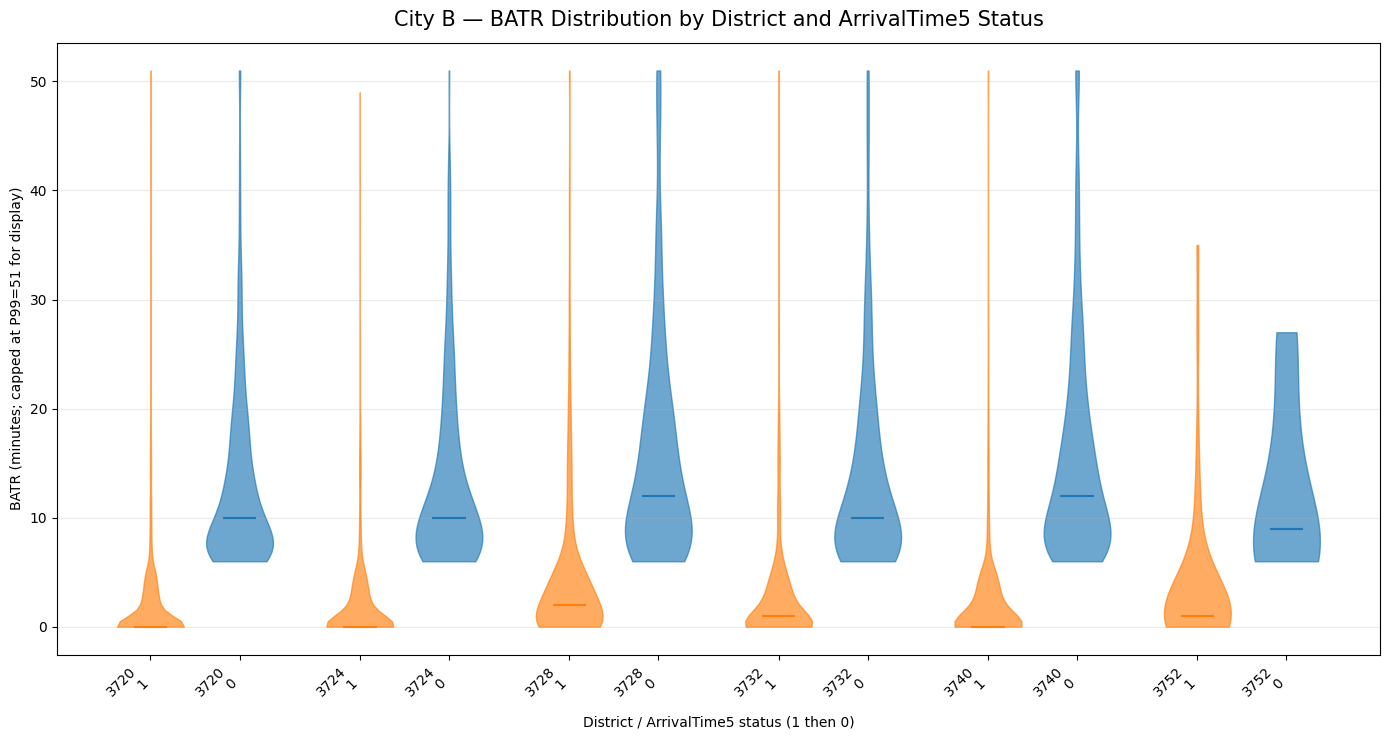

,order_city,district,ArrivalTime5,Orders,BATR_Mean,BATR_Median,BATR_P90,BATR15 Success (%)
1,B,3720,1,7881,2.34,0.00,6.00,96.99
0,B,3720,0,1579,14.03,10.00,24.00,72.58
3,B,3724,1,2893,2.24,0.00,5.00,97.23
2,B,3724,0,559,13.24,10.00,25.00,72.45
5,B,3728,1,1102,4.52,2.00,13.00,92.74
4,B,3728,0,521,18.44,12.00,30.00,62.00
7,B,3732,1,1713,2.87,1.00,7.00,96.03
6,B,3732,0,468,14.07,10.00,26.30,71.37
9,B,3740,1,2985,2.88,0.00,5.00,96.42
8,B,3740,0,1558,19.19,12.00,29.00,63.61



CITY K — ARRIVAL / BATR VIOLIN


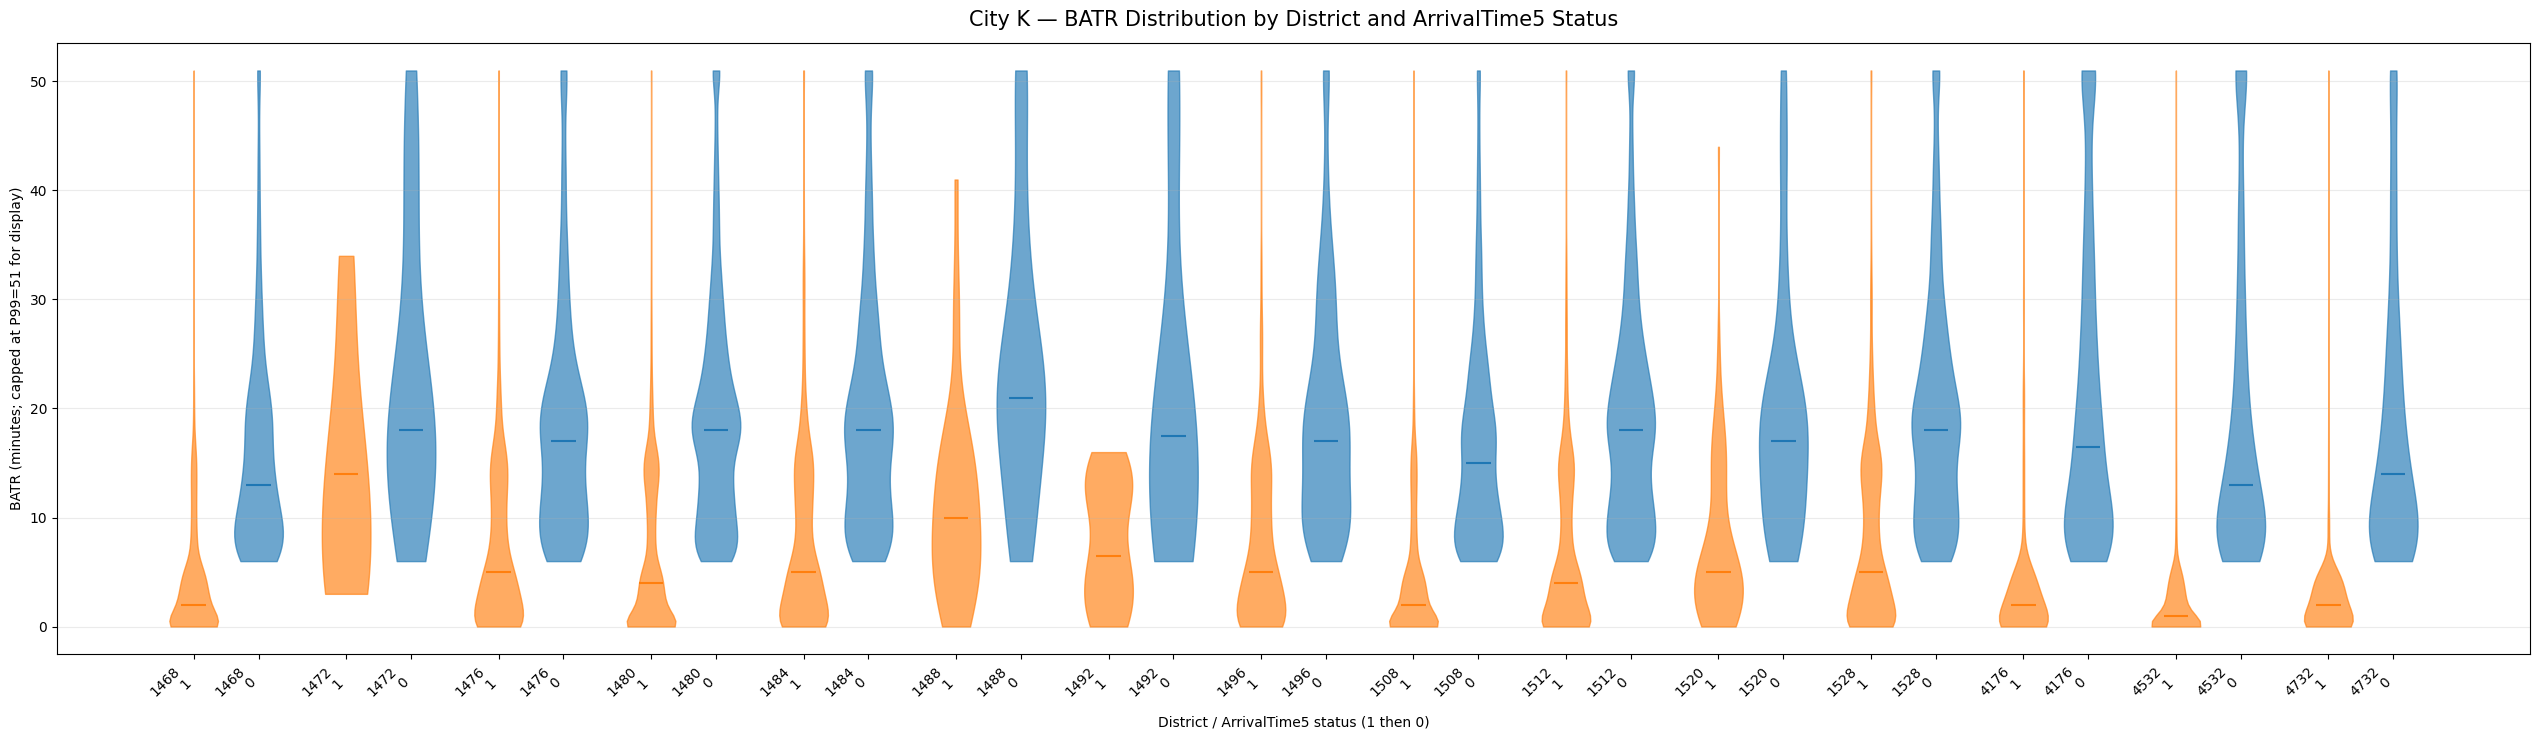

,order_city,district,ArrivalTime5,Orders,BATR_Mean,BATR_Median,BATR_P90,BATR15 Success (%)
13,K,1468,1,2663,4.19,2.00,12.00,95.23
12,K,1468,0,1326,15.98,13.00,28.00,58.90
15,K,1472,1,9,13.44,14.00,27.60,66.67
14,K,1472,0,16,22.81,18.00,42.50,25.00
17,K,1476,1,2003,7.01,5.00,16.00,87.72
16,K,1476,0,1256,38.26,17.00,32.50,45.38
19,K,1480,1,17093,6.75,4.00,16.00,87.63
18,K,1480,0,9800,23.13,18.00,33.00,39.76
21,K,1484,1,3274,7.86,5.00,17.00,84.94
20,K,1484,0,2136,20.22,18.00,35.00,41.15



CITY U — ARRIVAL / BATR VIOLIN


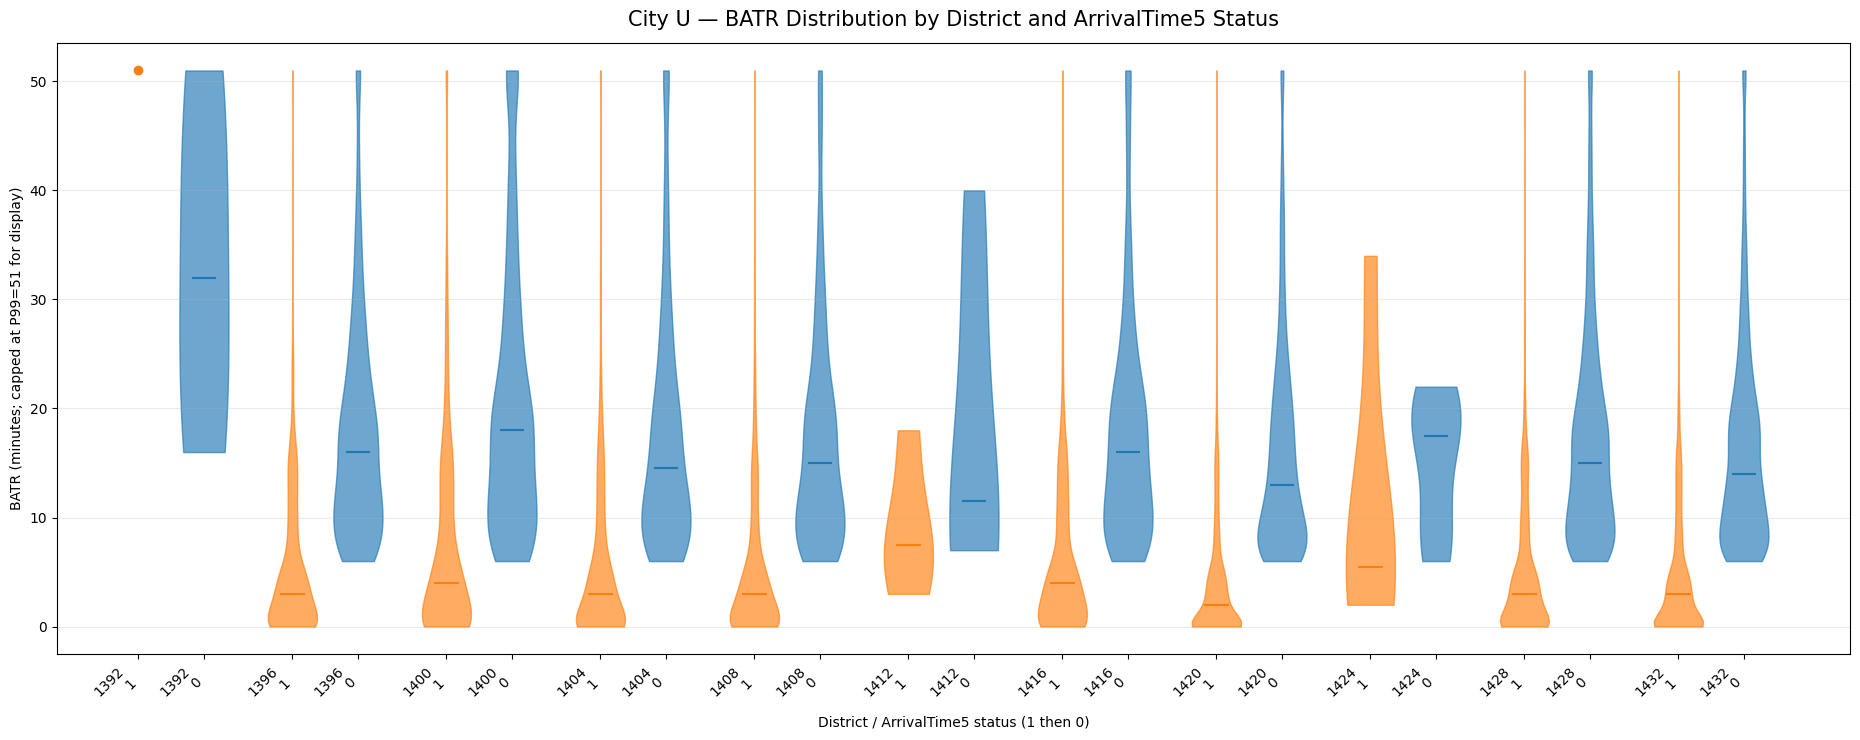

,order_city,district,ArrivalTime5,Orders,BATR_Mean,BATR_Median,BATR_P90,BATR15 Success (%)
43,U,1392,1,1,57.00,57.00,57.00,0.00
42,U,1392,0,4,35.00,32.00,54.00,0.00
45,U,1396,1,2289,5.65,3.00,15.00,91.48
44,U,1396,0,1180,18.18,16.00,32.00,48.98
47,U,1400,1,2717,8.25,4.00,19.00,84.50
46,U,1400,0,1445,25.59,18.00,41.00,42.21
49,U,1404,1,2822,5.64,3.00,16.00,89.48
48,U,1404,0,1194,20.54,14.50,34.00,53.43
51,U,1408,1,1811,5.15,3.00,14.00,92.10
50,U,1408,0,1012,17.89,15.00,31.00,52.87


In [17]:
arrival_district_batr_summary = (
    arrival_batr.groupby(["order_city", "district", "ArrivalTime5"])
                .agg(
                    Orders=("order_id", "count"),
                    BATR_Mean=("BATR_min", "mean"),
                    BATR_Median=("BATR_min", "median"),
                    BATR_P90=("BATR_min", lambda s: s.quantile(0.90)),
                    BATR15_Success=("BATR15", "mean")
                )
                .reset_index()
)

arrival_district_batr_summary["BATR15 Success (%)"] = (
    arrival_district_batr_summary["BATR15_Success"] * 100
)


def plot_arrival_district_violins(city):
    city_data = arrival_batr[arrival_batr["order_city"] == city].copy()
    districts = sorted(city_data["district"].dropna().unique())

    fig_width = max(14, len(districts) * 1.7)
    fig, ax = plt.subplots(figsize=(fig_width, 7.5))

    positions, labels = [], []
    pos = 1

    for district in districts:
        for status in [1, 0]:
            vals = city_data.loc[
                (city_data["district"] == district)
                & (city_data["ArrivalTime5"] == status),
                "BATR_plot_min"
            ].dropna().values

            if len(vals) >= 2 and np.nanstd(vals) > 0:
                parts = ax.violinplot(
                    vals,
                    positions=[pos],
                    widths=0.75,
                    showmeans=False,
                    showmedians=True,
                    showextrema=False
                )
                color_violin(parts, COLOR_1 if status == 1 else COLOR_0)
            elif len(vals) >= 1:
                ax.scatter(
                    [pos],
                    [np.nanmedian(vals)],
                    color=COLOR_1 if status == 1 else COLOR_0
                )

            positions.append(pos)
            labels.append(f"{int(district)}\n{status}")
            pos += 1

        pos += 0.35

    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_title(
        f"City {city} — BATR Distribution by District and ArrivalTime5 Status",
        fontsize=15,
        pad=12
    )
    ax.set_xlabel("District / ArrivalTime5 status (1 then 0)")
    ax.set_ylabel(
        f"BATR (minutes; capped at P99={ARRIVAL_BATR_P99:.0f} for display)"
    )
    ax.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

    return (
        arrival_district_batr_summary[
            arrival_district_batr_summary["order_city"] == city
        ]
        .sort_values(
            ["district", "ArrivalTime5"],
            ascending=[True, False]
        )
        [
            [
                "order_city", "district", "ArrivalTime5", "Orders",
                "BATR_Mean", "BATR_Median", "BATR_P90",
                "BATR15 Success (%)"
            ]
        ]
    )


for city in ["B", "K", "U"]:
    print("\n" + "=" * 80)
    print(f"CITY {city} — ARRIVAL / BATR VIOLIN")
    print("=" * 80)
    display(plot_arrival_district_violins(city))


In [18]:
component_valid = df[
    df["BATR15"].notna()
    & df["AcceptanceTime10"].notna()
    & df["ArrivalTime5"].notna()
].copy()

component_valid["BATR15"] = component_valid["BATR15"].astype(int)
component_valid["AcceptanceTime10"] = component_valid["AcceptanceTime10"].astype(int)
component_valid["ArrivalTime5"] = component_valid["ArrivalTime5"].astype(int)

late = component_valid[component_valid["BATR15"] == 0].copy()

late["Acceptance_Fail"] = (late["AcceptanceTime10"] == 0).astype(int)
late["Arrival_Fail"] = (late["ArrivalTime5"] == 0).astype(int)

late["Failure_Source"] = np.select(
    [
        (late["AcceptanceTime10"] == 0) & (late["ArrivalTime5"] == 1),
        (late["AcceptanceTime10"] == 1) & (late["ArrivalTime5"] == 0),
        (late["AcceptanceTime10"] == 0) & (late["ArrivalTime5"] == 0)
    ],
    [
        "Acceptance only",
        "Arrival only",
        "Both"
    ],
    default="Neither"
)

source_order = [
    "Acceptance only",
    "Arrival only",
    "Both",
    "Neither"
]

overall_accept_share = late["Acceptance_Fail"].mean() * 100
overall_arrival_share = late["Arrival_Fail"].mean() * 100
overall_driver_gap = overall_accept_share - overall_arrival_share

print(f"Late BATR orders used: {len(late):,}")
print(f"Overall acceptance-failure share among late BATR: {overall_accept_share:.2f}%")
print(f"Overall arrival-failure share among late BATR: {overall_arrival_share:.2f}%")
print(f"Overall driver gap (Acceptance - Arrival): {overall_driver_gap:.2f} pp")


Late BATR orders used: 34,177
Overall acceptance-failure share among late BATR: 72.34%
Overall arrival-failure share among late BATR: 74.42%
Overall driver gap (Acceptance - Arrival): -2.08 pp


In [19]:
city_driver = (
    late.groupby("order_city")
        .agg(
            Late_BATR_Orders=("order_id", "count"),
            Acceptance_Fail_Share=("Acceptance_Fail", "mean"),
            Arrival_Fail_Share=("Arrival_Fail", "mean")
        )
        .reset_index()
        .rename(columns={"order_city": "City"})
)

city_driver["Acceptance Fail among BATR0 (%)"] = (
    city_driver["Acceptance_Fail_Share"] * 100
)
city_driver["Arrival Fail among BATR0 (%)"] = (
    city_driver["Arrival_Fail_Share"] * 100
)

city_exclusive = (
    late.groupby(["order_city", "Failure_Source"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=source_order, fill_value=0)
)

city_exclusive_pct = (
    city_exclusive.div(city_exclusive.sum(axis=1), axis=0) * 100
).reset_index().rename(columns={"order_city": "City"})

city_driver = city_driver.merge(
    city_exclusive_pct,
    on="City",
    how="left"
)

city_driver["Driver Gap (pp)"] = (
    city_driver["Acceptance Fail among BATR0 (%)"]
    - city_driver["Arrival Fail among BATR0 (%)"]
)

city_driver["Gap vs Overall (pp)"] = (
    city_driver["Driver Gap (pp)"] - overall_driver_gap
)

city_driver["Primary Association"] = np.where(
    city_driver["Driver Gap (pp)"] > 0,
    "Acceptance-heavy",
    np.where(
        city_driver["Driver Gap (pp)"] < 0,
        "Arrival-heavy",
        "Balanced"
    )
)

city_driver = city_driver[
    [
        "City",
        "Late_BATR_Orders",
        "Acceptance Fail among BATR0 (%)",
        "Arrival Fail among BATR0 (%)",
        "Acceptance only",
        "Arrival only",
        "Both",
        "Neither",
        "Driver Gap (pp)",
        "Gap vs Overall (pp)",
        "Primary Association"
    ]
].sort_values("Driver Gap (pp)", ascending=False)

display(city_driver)


,City,Late_BATR_Orders,Acceptance Fail among BATR0 (%),Arrival Fail among BATR0 (%),Acceptance only,Arrival only,Both,Neither,Driver Gap (pp),Gap vs Overall (pp),Primary Association
2,U,10359,72.99,72.96,27.04,27.01,45.95,0.00,0.03,2.11,Acceptance-heavy
1,K,21753,73.39,75.32,24.68,26.61,48.71,0.00,-1.94,0.14,Arrival-heavy
0,B,2065,57.97,72.15,27.85,42.03,30.12,0.00,-14.19,-12.11,Arrival-heavy


In [20]:
district_driver = (
    late.groupby(["order_city", "district"])
        .agg(
            Late_BATR_Orders=("order_id", "count"),
            Acceptance_Fail_Share=("Acceptance_Fail", "mean"),
            Arrival_Fail_Share=("Arrival_Fail", "mean")
        )
        .reset_index()
)

district_driver["Acceptance Fail among BATR0 (%)"] = (
    district_driver["Acceptance_Fail_Share"] * 100
)
district_driver["Arrival Fail among BATR0 (%)"] = (
    district_driver["Arrival_Fail_Share"] * 100
)

district_exclusive = (
    late.groupby(["order_city", "district", "Failure_Source"])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=source_order, fill_value=0)
)

district_exclusive_pct = (
    district_exclusive.div(
        district_exclusive.sum(axis=1),
        axis=0
    ) * 100
).reset_index()

district_driver = district_driver.merge(
    district_exclusive_pct,
    on=["order_city", "district"],
    how="left"
)

district_driver["Driver Gap (pp)"] = (
    district_driver["Acceptance Fail among BATR0 (%)"]
    - district_driver["Arrival Fail among BATR0 (%)"]
)

city_gap_lookup = (
    city_driver.set_index("City")["Driver Gap (pp)"].to_dict()
)

district_driver["City Driver Gap (pp)"] = (
    district_driver["order_city"].map(city_gap_lookup)
)

district_driver["Relative Driver Gap vs City (pp)"] = (
    district_driver["Driver Gap (pp)"]
    - district_driver["City Driver Gap (pp)"]
)

district_driver["Primary Association"] = np.where(
    district_driver["Driver Gap (pp)"] > 0,
    "Acceptance-heavy",
    np.where(
        district_driver["Driver Gap (pp)"] < 0,
        "Arrival-heavy",
        "Balanced"
    )
)

district_driver["Relative to City Peers"] = np.where(
    district_driver["Relative Driver Gap vs City (pp)"] > 5,
    "More acceptance-heavy than city",
    np.where(
        district_driver["Relative Driver Gap vs City (pp)"] < -5,
        "More arrival-heavy than city",
        "Close to city mix"
    )
)

district_driver_table = district_driver[
    [
        "order_city",
        "district",
        "Late_BATR_Orders",
        "Acceptance Fail among BATR0 (%)",
        "Arrival Fail among BATR0 (%)",
        "Acceptance only",
        "Arrival only",
        "Both",
        "Neither",
        "Driver Gap (pp)",
        "City Driver Gap (pp)",
        "Relative Driver Gap vs City (pp)",
        "Primary Association",
        "Relative to City Peers"
    ]
].sort_values(
    ["order_city", "Relative Driver Gap vs City (pp)"],
    ascending=[True, False]
)

display(district_driver_table)


,order_city,district,Late_BATR_Orders,Acceptance Fail among BATR0 (%),Arrival Fail among BATR0 (%),Acceptance only,Arrival only,Both,Neither,Driver Gap (pp),City Driver Gap (pp),Relative Driver Gap vs City (pp),Primary Association,Relative to City Peers
5,B,3752,7,71.43,57.14,42.86,28.57,28.57,0.00,14.29,-14.19,28.47,Acceptance-heavy,More acceptance-heavy than city
3,B,3732,202,69.80,66.34,33.66,30.20,36.14,0.00,3.47,-14.19,17.65,Acceptance-heavy,More acceptance-heavy than city
1,B,3724,234,65.81,65.81,34.19,34.19,31.62,0.00,0.00,-14.19,14.19,Balanced,More acceptance-heavy than city
0,B,3720,670,64.18,64.63,35.37,35.82,28.81,0.00,-0.45,-14.19,13.74,Arrival-heavy,More acceptance-heavy than city
2,B,3728,278,67.99,71.22,28.78,32.01,39.21,0.00,-3.24,-14.19,10.95,Arrival-heavy,More acceptance-heavy than city
4,B,3740,674,41.25,84.12,15.88,58.75,25.37,0.00,-42.88,-14.19,-28.69,Arrival-heavy,More arrival-heavy than city
17,K,1528,2392,84.36,70.28,29.72,15.64,54.64,0.00,14.09,-1.94,16.02,Acceptance-heavy,More acceptance-heavy than city
12,K,1492,8,100.00,87.50,12.50,0.00,87.50,0.00,12.50,-1.94,14.44,Acceptance-heavy,More acceptance-heavy than city
15,K,1512,3367,81.08,72.94,27.06,18.92,54.02,0.00,8.14,-1.94,10.07,Acceptance-heavy,More acceptance-heavy than city
8,K,1476,932,80.90,73.61,26.39,19.10,54.51,0.00,7.30,-1.94,9.23,Acceptance-heavy,More acceptance-heavy than city


In [21]:
peer_rank = district_driver_table[
    district_driver_table["Late_BATR_Orders"] >= 30
].copy()

print("MOST ACCEPTANCE-HEAVY RELATIVE TO THEIR CITY")
display(
    peer_rank.sort_values(
        "Relative Driver Gap vs City (pp)",
        ascending=False
    ).head(15)
)

print("\nMOST ARRIVAL-HEAVY RELATIVE TO THEIR CITY")
display(
    peer_rank.sort_values(
        "Relative Driver Gap vs City (pp)",
        ascending=True
    ).head(15)
)


MOST ACCEPTANCE-HEAVY RELATIVE TO THEIR CITY


,order_city,district,Late_BATR_Orders,Acceptance Fail among BATR0 (%),Arrival Fail among BATR0 (%),Acceptance only,Arrival only,Both,Neither,Driver Gap (pp),City Driver Gap (pp),Relative Driver Gap vs City (pp),Primary Association,Relative to City Peers
3,B,3732,202,69.80,66.34,33.66,30.20,36.14,0.00,3.47,-14.19,17.65,Acceptance-heavy,More acceptance-heavy than city
17,K,1528,2392,84.36,70.28,29.72,15.64,54.64,0.00,14.09,-1.94,16.02,Acceptance-heavy,More acceptance-heavy than city
23,U,1400,1256,82.48,66.48,33.52,17.52,48.96,0.00,16.00,0.03,15.97,Acceptance-heavy,More acceptance-heavy than city
1,B,3724,234,65.81,65.81,34.19,34.19,31.62,0.00,0.00,-14.19,14.19,Balanced,More acceptance-heavy than city
0,B,3720,670,64.18,64.63,35.37,35.82,28.81,0.00,-0.45,-14.19,13.74,Arrival-heavy,More acceptance-heavy than city
24,U,1404,853,76.91,65.18,34.82,23.09,42.09,0.00,11.72,0.03,11.69,Acceptance-heavy,More acceptance-heavy than city
2,B,3728,278,67.99,71.22,28.78,32.01,39.21,0.00,-3.24,-14.19,10.95,Arrival-heavy,More acceptance-heavy than city
15,K,1512,3367,81.08,72.94,27.06,18.92,54.02,0.00,8.14,-1.94,10.07,Acceptance-heavy,More acceptance-heavy than city
8,K,1476,932,80.90,73.61,26.39,19.10,54.51,0.00,7.30,-1.94,9.23,Acceptance-heavy,More acceptance-heavy than city
11,K,1488,43,88.37,81.40,18.60,11.63,69.77,0.00,6.98,-1.94,8.91,Acceptance-heavy,More acceptance-heavy than city



MOST ARRIVAL-HEAVY RELATIVE TO THEIR CITY


,order_city,district,Late_BATR_Orders,Acceptance Fail among BATR0 (%),Arrival Fail among BATR0 (%),Acceptance only,Arrival only,Both,Neither,Driver Gap (pp),City Driver Gap (pp),Relative Driver Gap vs City (pp),Primary Association,Relative to City Peers
20,K,4732,371,20.22,94.34,5.66,79.78,14.56,0.00,-74.12,-1.94,-72.19,Arrival-heavy,More arrival-heavy than city
19,K,4532,804,22.76,89.93,10.07,77.24,12.69,0.00,-67.16,-1.94,-65.23,Arrival-heavy,More arrival-heavy than city
18,K,4176,1187,34.63,89.05,10.95,65.37,23.67,0.00,-54.42,-1.94,-52.49,Arrival-heavy,More arrival-heavy than city
4,B,3740,674,41.25,84.12,15.88,58.75,25.37,0.00,-42.88,-14.19,-28.69,Arrival-heavy,More arrival-heavy than city
6,K,1468,672,62.50,81.10,18.90,37.50,43.60,0.00,-18.60,-1.94,-16.67,Arrival-heavy,More arrival-heavy than city
30,U,1428,1945,68.02,77.79,22.21,31.98,45.81,0.00,-9.77,0.03,-9.80,Arrival-heavy,More arrival-heavy than city
25,U,1408,620,68.55,76.94,23.06,31.45,45.48,0.00,-8.39,0.03,-8.42,Arrival-heavy,More arrival-heavy than city
14,K,1508,1709,67.88,76.48,23.52,32.12,44.35,0.00,-8.60,-1.94,-6.67,Arrival-heavy,More arrival-heavy than city
27,U,1416,814,71.74,77.03,22.97,28.26,48.77,0.00,-5.28,0.03,-5.31,Arrival-heavy,More arrival-heavy than city
31,U,1432,2374,70.98,74.35,25.65,29.02,45.32,0.00,-3.37,0.03,-3.40,Arrival-heavy,Close to city mix


In [22]:
for city in ["B", "K", "U"]:
    print("\n" + "=" * 100)
    print(f"CITY {city} — BATR0 COMPONENT DIAGNOSTIC")
    print("=" * 100)

    table = (
        district_driver_table[
            district_driver_table["order_city"] == city
        ]
        .sort_values(
            "Relative Driver Gap vs City (pp)",
            ascending=False
        )
    )

    display(table)



CITY B — BATR0 COMPONENT DIAGNOSTIC


,order_city,district,Late_BATR_Orders,Acceptance Fail among BATR0 (%),Arrival Fail among BATR0 (%),Acceptance only,Arrival only,Both,Neither,Driver Gap (pp),City Driver Gap (pp),Relative Driver Gap vs City (pp),Primary Association,Relative to City Peers
5,B,3752,7,71.43,57.14,42.86,28.57,28.57,0.00,14.29,-14.19,28.47,Acceptance-heavy,More acceptance-heavy than city
3,B,3732,202,69.80,66.34,33.66,30.20,36.14,0.00,3.47,-14.19,17.65,Acceptance-heavy,More acceptance-heavy than city
1,B,3724,234,65.81,65.81,34.19,34.19,31.62,0.00,0.00,-14.19,14.19,Balanced,More acceptance-heavy than city
0,B,3720,670,64.18,64.63,35.37,35.82,28.81,0.00,-0.45,-14.19,13.74,Arrival-heavy,More acceptance-heavy than city
2,B,3728,278,67.99,71.22,28.78,32.01,39.21,0.00,-3.24,-14.19,10.95,Arrival-heavy,More acceptance-heavy than city
4,B,3740,674,41.25,84.12,15.88,58.75,25.37,0.00,-42.88,-14.19,-28.69,Arrival-heavy,More arrival-heavy than city



CITY K — BATR0 COMPONENT DIAGNOSTIC


,order_city,district,Late_BATR_Orders,Acceptance Fail among BATR0 (%),Arrival Fail among BATR0 (%),Acceptance only,Arrival only,Both,Neither,Driver Gap (pp),City Driver Gap (pp),Relative Driver Gap vs City (pp),Primary Association,Relative to City Peers
17,K,1528,2392,84.36,70.28,29.72,15.64,54.64,0.00,14.09,-1.94,16.02,Acceptance-heavy,More acceptance-heavy than city
12,K,1492,8,100.00,87.50,12.50,0.00,87.50,0.00,12.50,-1.94,14.44,Acceptance-heavy,More acceptance-heavy than city
15,K,1512,3367,81.08,72.94,27.06,18.92,54.02,0.00,8.14,-1.94,10.07,Acceptance-heavy,More acceptance-heavy than city
8,K,1476,932,80.90,73.61,26.39,19.10,54.51,0.00,7.30,-1.94,9.23,Acceptance-heavy,More acceptance-heavy than city
11,K,1488,43,88.37,81.40,18.60,11.63,69.77,0.00,6.98,-1.94,8.91,Acceptance-heavy,More acceptance-heavy than city
10,K,1484,1750,78.57,71.83,28.17,21.43,50.40,0.00,6.74,-1.94,8.68,Acceptance-heavy,More acceptance-heavy than city
9,K,1480,8018,79.76,73.63,26.37,20.24,53.39,0.00,6.12,-1.94,8.06,Acceptance-heavy,More acceptance-heavy than city
13,K,1496,400,79.75,74.50,25.50,20.25,54.25,0.00,5.25,-1.94,7.19,Acceptance-heavy,More acceptance-heavy than city
16,K,1520,85,78.82,78.82,21.18,21.18,57.65,0.00,0.00,-1.94,1.94,Balanced,Close to city mix
7,K,1472,15,73.33,80.00,20.00,26.67,53.33,0.00,-6.67,-1.94,-4.73,Arrival-heavy,Close to city mix



CITY U — BATR0 COMPONENT DIAGNOSTIC


,order_city,district,Late_BATR_Orders,Acceptance Fail among BATR0 (%),Arrival Fail among BATR0 (%),Acceptance only,Arrival only,Both,Neither,Driver Gap (pp),City Driver Gap (pp),Relative Driver Gap vs City (pp),Primary Association,Relative to City Peers
23,U,1400,1256,82.48,66.48,33.52,17.52,48.96,0.00,16.00,0.03,15.97,Acceptance-heavy,More acceptance-heavy than city
24,U,1404,853,76.91,65.18,34.82,23.09,42.09,0.00,11.72,0.03,11.69,Acceptance-heavy,More acceptance-heavy than city
28,U,1420,1685,72.28,69.50,30.50,27.72,41.78,0.00,2.79,0.03,2.76,Acceptance-heavy,Close to city mix
22,U,1396,797,78.04,75.53,24.47,21.96,53.58,0.00,2.51,0.03,2.48,Acceptance-heavy,Close to city mix
21,U,1392,5,80.00,80.00,20.00,20.00,60.00,0.00,0.00,0.03,-0.03,Balanced,Close to city mix
26,U,1412,4,75.00,75.00,25.00,25.00,50.00,0.00,0.00,0.03,-0.03,Balanced,Close to city mix
29,U,1424,6,83.33,83.33,16.67,16.67,66.67,0.00,0.00,0.03,-0.03,Balanced,Close to city mix
31,U,1432,2374,70.98,74.35,25.65,29.02,45.32,0.00,-3.37,0.03,-3.40,Arrival-heavy,Close to city mix
27,U,1416,814,71.74,77.03,22.97,28.26,48.77,0.00,-5.28,0.03,-5.31,Arrival-heavy,More arrival-heavy than city
25,U,1408,620,68.55,76.94,23.06,31.45,45.48,0.00,-8.39,0.03,-8.42,Arrival-heavy,More arrival-heavy than city
